In [78]:
# ── Setup ──────────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import os

# ── Output directory ───────────────────────────────────────────────────────
FIGURES_DIR = 'Results/Figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Shared plot style ──────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', context='paper')
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

# ── University of Nottingham brand colours ─────────────────────────────────
# Source: https://www.nottingham.ac.uk/brand/visual/colour.aspx
UON_BLUE        = '#10263B'  # Nottingham Blue       – primary / ResNet-18
UON_SKY         = '#009BC1'  # Malaysia Sky Blue     – secondary / ResNet-50
UON_TURQUOISE   = '#37B4B0'  # Trent Turquoise       – CIFAR-10
UON_PURPLE      = '#792D85'  # Civic Purple          – CIFAR-100
UON_RED         = '#B91C2E'  # Jubilee Red           – ImageNet
UON_ORANGE      = '#F98109'  # Mandarin Orange       – FGSM
UON_GOLD        = '#DEB406'  # Rebel's Gold          – PGD
UON_PINK        = '#D7336C'  # Pioneering Pink       – APGD
UON_GREEN       = '#005F36'  # Forest Green          – defence / positive
UON_STONE       = '#FAF6EF'  # Portland Stone        – neutral background

# Convenience groupings
PALETTE_MODELS   = {'ResNet-18': UON_BLUE,    'ResNet-50': UON_SKY}
PALETTE_DATASETS = {'CIFAR-10': UON_TURQUOISE, 'CIFAR-100': UON_PURPLE, 'ImageNet': UON_RED}
PALETTE_ATTACKS  = {'fgsm': UON_ORANGE, 'pgd': UON_GOLD, 'apgd': UON_PINK}

# ── Load results ──────────────────────────────────────────────────────────
df_c10  = pd.read_excel('Results/CIFAR-10/CIFAR-10_Full_Results.xlsx')
df_c100 = pd.read_excel('Results/CIFAR-100/CIFAR-100_Full_Results.xlsx')
df_in18 = pd.read_excel('Results/ImageNet/ImageNet_ResNet18_Results.xlsx')
df_in50 = pd.read_excel('Results/ImageNet/ImageNet_ResNet50_Results.xlsx')

df_c10['dataset']  = 'CIFAR-10'
df_c100['dataset'] = 'CIFAR-100'
df_in18['dataset'] = 'ImageNet'
df_in50['dataset'] = 'ImageNet'

# Combined CIFAR frame
df_cifar = pd.concat([df_c10, df_c100], ignore_index=True)

# Combined ImageNet frame (both models)
df_imagenet = pd.concat([df_in18, df_in50], ignore_index=True)

# All datasets
df_all = pd.concat([df_cifar, df_imagenet], ignore_index=True)

# ── Pipeline categorisation ────────────────────────────────────────────────
def categorize_pipeline(row):
    p = str(row['pipeline'])
    has_attack = pd.notna(row['attack'])
    has_comp   = pd.notna(row['compression'])
    if p == 'clean':
        return 'Clean'
    if has_attack and not has_comp:
        return 'Attack Only'
    if has_comp and not has_attack:
        return 'Compression Only'
    if '->' in p:
        parts = p.split('->')
        first = parts[0].strip()
        if any(a in first for a in ['fgsm', 'pgd', 'apgd']):
            return 'Defend (Attack→Comp)'
        else:
            return 'Compound (Comp→Attack)'
    return 'Other'

for _df in [df_cifar, df_imagenet, df_all]:
    _df['pipeline_type'] = _df.apply(categorize_pipeline, axis=1)
    _df['model_arch']    = _df['model'].str.split('_').str[0]

# ── Convenience ───────────────────────────────────────────────────────────
COMP_LABELS = {
    'jpeg':     'JPEG',
    'jpeg2000': 'JPEG2000',
    'pca':      'PCA',
    'patchsvd': 'PatchSVD',
    'lic_roi':  'LIC-ROI',
}
ATTACK_LABELS = {'fgsm': 'FGSM', 'pgd': 'PGD', 'apgd': 'APGD'}

def save_fig(name):
    path = os.path.join(FIGURES_DIR, f'{name}.png')
    plt.savefig(path, bbox_inches='tight')
    print(f'Saved → {path}')

# ── CAC (triple pipeline) results ────────────────────────────────────────
df_cac_c10  = pd.read_excel('Results/CIFAR-10/CIFAR-10_CAC.xlsx')
df_cac_c100 = pd.read_excel('Results/CIFAR-100/CIFAR-100_CAC.xlsx')
df_cac_c10['dataset']  = 'CIFAR-10'
df_cac_c100['dataset'] = 'CIFAR-100'
df_cac = pd.concat([df_cac_c10, df_cac_c100], ignore_index=True)
df_cac['model_arch'] = df_cac['model'].str.split('_').str[0]

print('Setup complete.')
print(f'  CIFAR-10:  {len(df_c10)} rows')
print(f'  CIFAR-100: {len(df_c100)} rows')
print(f'  ImageNet ResNet18: {len(df_in18)} rows')
print(f'  ImageNet ResNet50: {len(df_in50)} rows')
print(f'  CAC (CIFAR): {len(df_cac)} rows')

Setup complete.
  CIFAR-10:  176 rows
  CIFAR-100: 176 rows
  ImageNet ResNet18: 109 rows
  ImageNet ResNet50: 109 rows
  CAC (CIFAR): 48 rows


Saved → Results/Figures/clean_baseline_accuracy.png


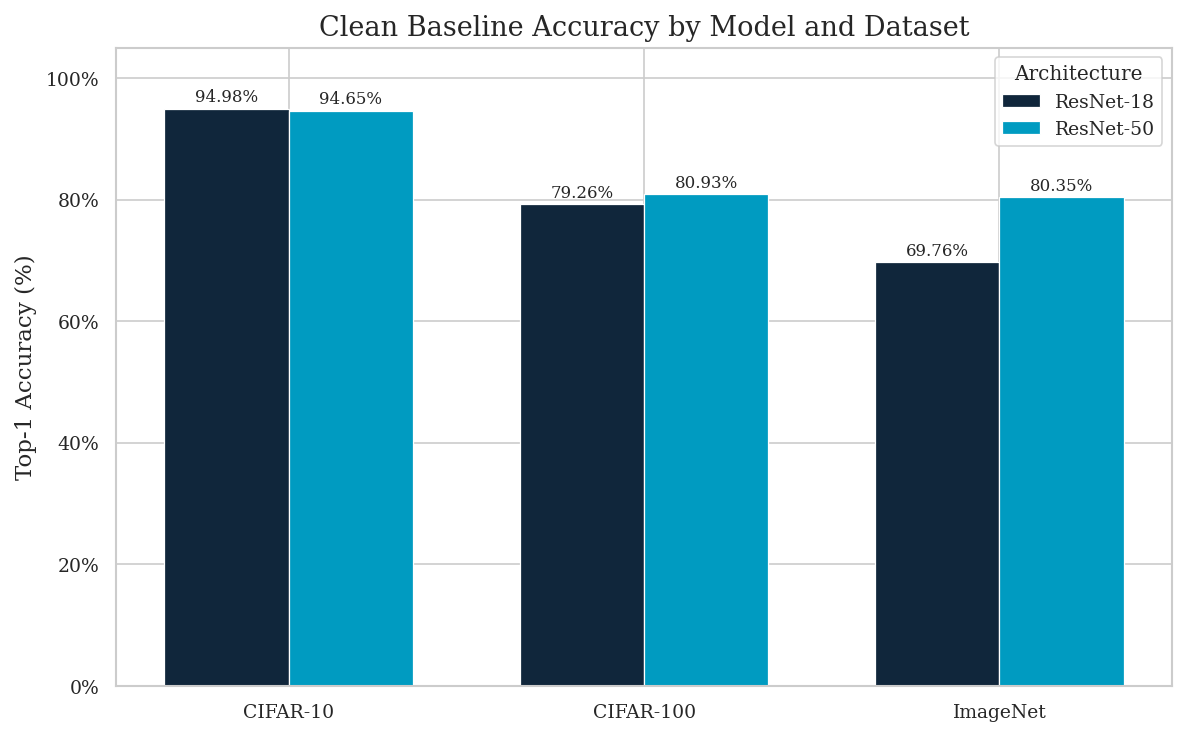

In [79]:
# Figure: Clean baseline accuracy across all six models and three datasets
# Supports: paragraph discussing competent classifiers, near-parity on CIFAR,
#           and substantial ResNet-18/50 divergence on ImageNet.

clean = df_all[df_all['pipeline_type'] == 'Clean'].copy()
clean['model_arch'] = clean['model_arch'].str.replace('resnet', 'ResNet-', regex=False)
clean['dataset'] = pd.Categorical(clean['dataset'], categories=['CIFAR-10', 'CIFAR-100', 'ImageNet'], ordered=True)
clean = clean.sort_values('dataset')

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(clean['dataset'].cat.categories))
width = 0.35

for i, (arch, group) in enumerate(clean.groupby('model_arch', sort=False)):
    group = group.sort_values('dataset')
    bars = ax.bar(
        x + (i - 0.5) * width,
        group['accuracy'] * 100,
        width,
        label=arch,
        color=PALETTE_MODELS[arch],
        edgecolor='white',
        linewidth=0.6,
    )
    for bar, val in zip(bars, group['accuracy'] * 100):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.2f}%',
            ha='center', va='bottom', fontsize=8
        )

ax.set_xticks(x)
ax.set_xticklabels(['CIFAR-10', 'CIFAR-100', 'ImageNet'])
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_ylim(0, 105)
ax.set_title('Clean Baseline Accuracy by Model and Dataset')
ax.legend(title='Architecture', frameon=True)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))

plt.tight_layout()
save_fig('clean_baseline_accuracy')
plt.show()

Saved → Results/Figures/attack_effectiveness_cifar.png


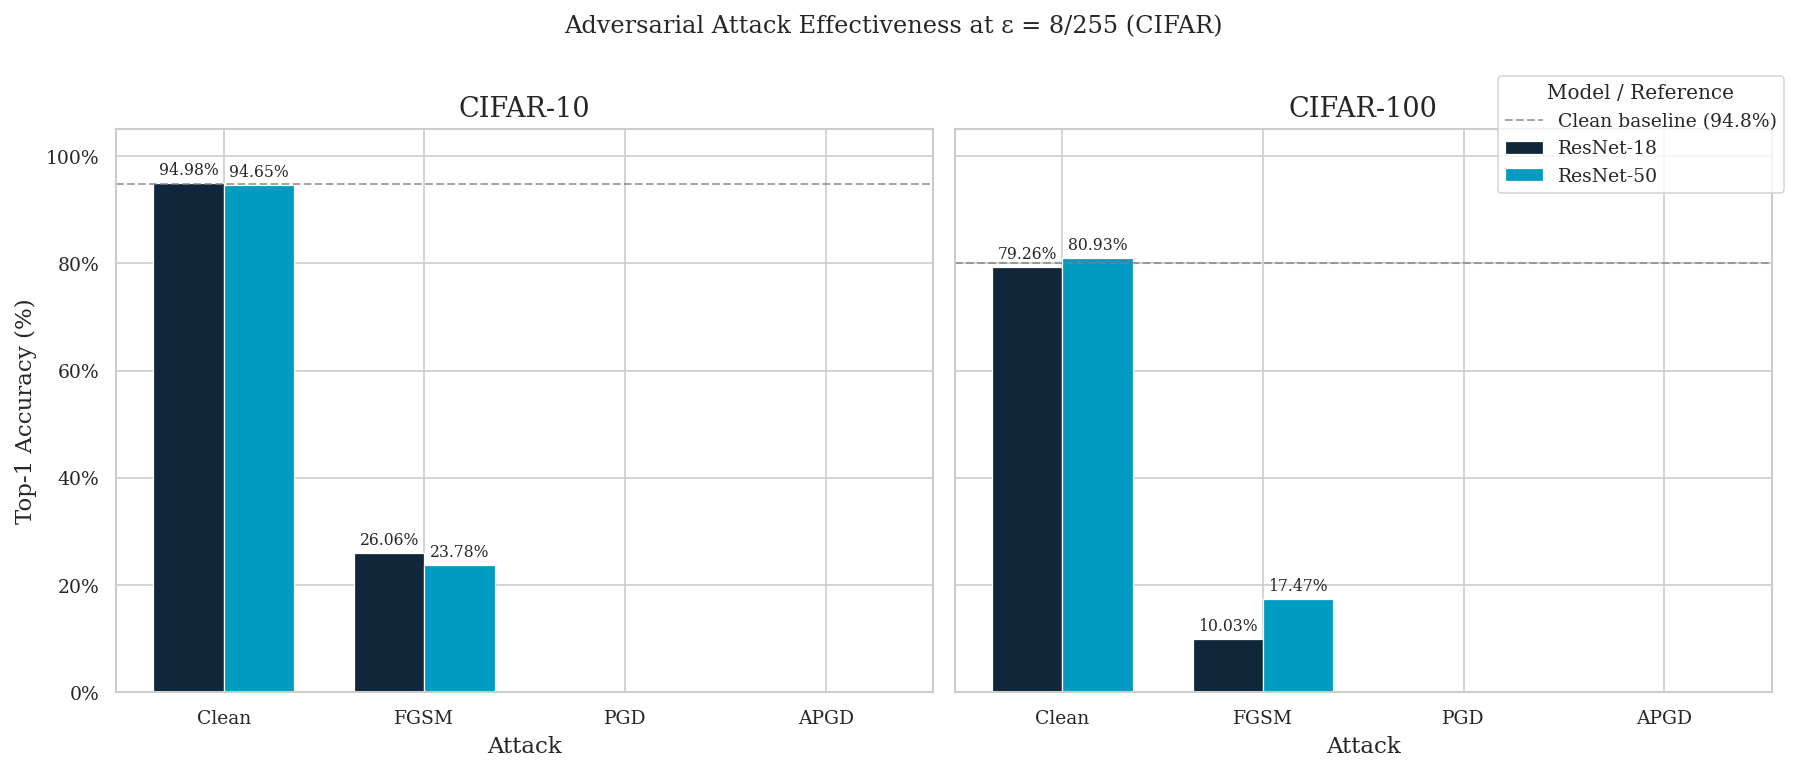

In [80]:
# Figure: Adversarial attack effectiveness on CIFAR-10 and CIFAR-100
# Supports: paragraph on catastrophic fragility of standard classifiers under
#           FGSM, PGD, and APGD at ε=8/255 — FGSM leaves residual accuracy,
#           PGD/APGD collapse both models to ~0%.

attacks = df_cifar[df_cifar['pipeline_type'].isin(['Clean', 'Attack Only'])].copy()
attacks['attack'] = attacks['attack'].fillna('Clean')
attacks['model_arch'] = attacks['model_arch'].str.replace('resnet', 'ResNet-', regex=False)
attacks['attack_label'] = attacks['attack'].map({**ATTACK_LABELS, 'Clean': 'Clean'})
attack_order = ['Clean', 'FGSM', 'PGD', 'APGD']
attacks['attack_label'] = pd.Categorical(attacks['attack_label'], categories=attack_order, ordered=True)

datasets = ['CIFAR-10', 'CIFAR-100']
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

x = np.arange(len(attack_order))
width = 0.35
arch_order = ['ResNet-18', 'ResNet-50']

for ax, dataset in zip(axes, datasets):
    subset = attacks[attacks['dataset'] == dataset]
    clean_acc = subset[subset['attack_label'] == 'Clean']['accuracy'].mean() * 100

    # Dashed clean baseline
    ax.axhline(clean_acc, color='grey', linestyle='--', linewidth=1, alpha=0.7,
               label=f'Clean baseline ({clean_acc:.1f}%)')

    for i, arch in enumerate(arch_order):
        arch_data = subset[subset['model_arch'] == arch].sort_values('attack_label')
        accs = []
        for atk in attack_order:
            row = arch_data[arch_data['attack_label'] == atk]
            accs.append(row['accuracy'].values[0] * 100 if len(row) else 0)

        bars = ax.bar(
            x + (i - 0.5) * width,
            accs,
            width,
            label=arch,
            color=PALETTE_MODELS[arch],
            edgecolor='white',
            linewidth=0.6,
        )
        for bar, val in zip(bars, accs):
            if val > 2:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.8,
                        f'{val:.2f}%',
                        ha='center', va='bottom', fontsize=7.5)

    ax.set_title(dataset)
    ax.set_xticks(x)
    ax.set_xticklabels(attack_order)
    ax.set_xlabel('Attack')
    ax.set_ylim(0, 105)

axes[0].set_ylabel('Top-1 Accuracy (%)')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))

# Combine legend entries (models + baseline) from first axis
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Model / Reference',
           loc='upper right', bbox_to_anchor=(1.0, 0.95), frameon=True)

fig.suptitle('Adversarial Attack Effectiveness at ε = 8/255 (CIFAR)', y=1.02)
plt.tight_layout()
save_fig('attack_effectiveness_cifar')
plt.show()

Saved → Results/Figures/compression_accuracy_psnr_cifar10_resnet18.png


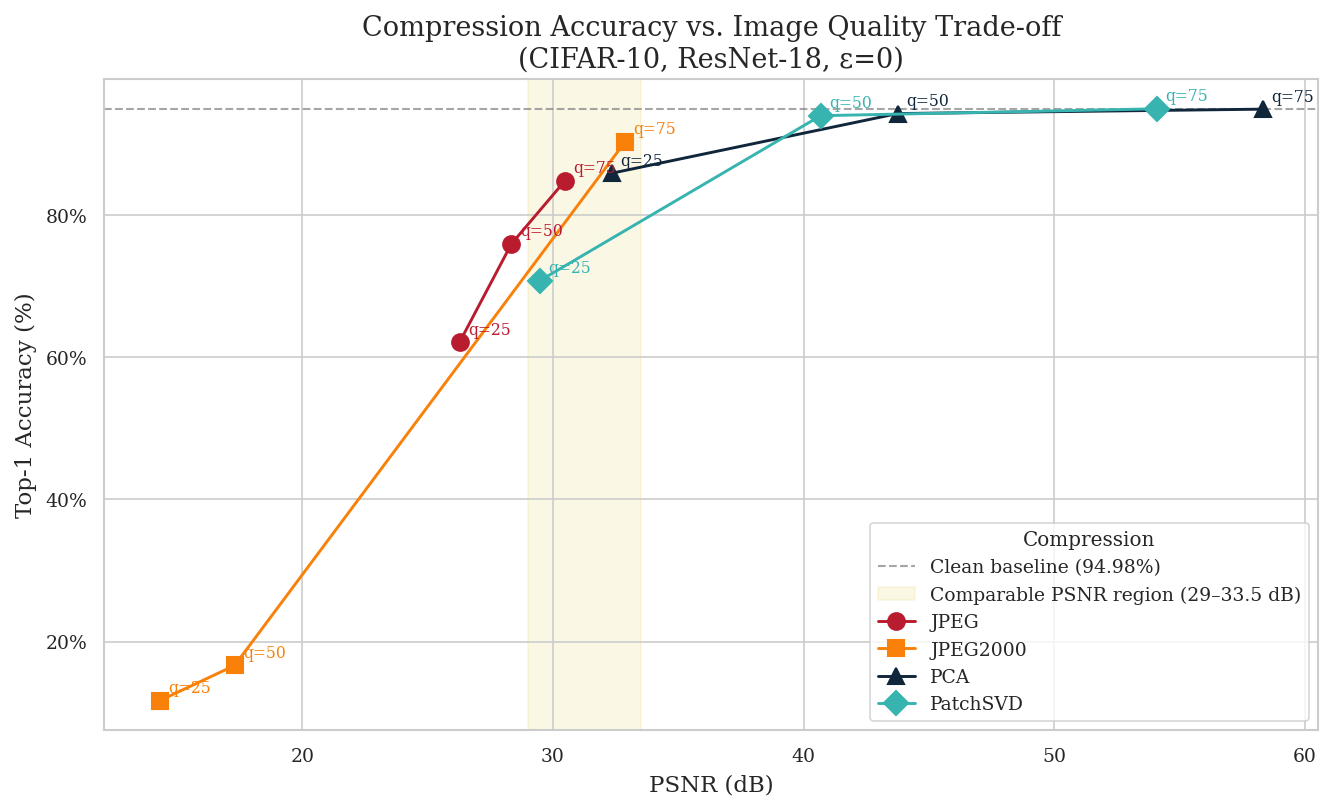

In [81]:
# Figure: Compression accuracy vs. PSNR trade-off on CIFAR-10 (ResNet-18)
# Supports: paragraph contrasting JPEG's aggressive accuracy/quality degradation
#           against PCA and PatchSVD's high-PSNR, near-clean accuracy behaviour.

c10 = df_cifar[df_cifar['dataset'] == 'CIFAR-10'].copy()

comp_only = c10[
    (c10['pipeline_type'] == 'Compression Only') &
    (c10['model'] == 'resnet18_cifar10')
].copy()
comp_only['comp_label'] = comp_only['compression'].map(COMP_LABELS)

# Clean baseline for reference line
clean_acc = c10[
    (c10['pipeline_type'] == 'Clean') &
    (c10['model'] == 'resnet18_cifar10')
]['accuracy'].values[0] * 100

COMP_PALETTE = {
    'JPEG':     UON_RED,
    'JPEG2000': UON_ORANGE,
    'PCA':      UON_BLUE,
    'PatchSVD': UON_TURQUOISE,
    'LIC-ROI':  UON_PURPLE,
}
MARKERS = {
    'JPEG':     'o',
    'JPEG2000': 's',
    'PCA':      '^',
    'PatchSVD': 'D',
    'LIC-ROI':  'P',
}

fig, ax = plt.subplots(figsize=(9, 5.5))

# Clean baseline
ax.axhline(clean_acc, color='grey', linestyle='--', linewidth=1, alpha=0.7,
           label=f'Clean baseline ({clean_acc:.2f}%)')

# Highlight comparable-PSNR region
ax.axvspan(29, 33.5, alpha=0.10, color=UON_GOLD, zorder=0,
           label='Comparable PSNR region (29–33.5 dB)')

for comp, group in comp_only.groupby('comp_label'):
    group = group.sort_values('quality')
    ax.plot(
        group['psnr_mean'], group['accuracy'] * 100,
        color=COMP_PALETTE[comp], marker=MARKERS[comp],
        linewidth=1.4, markersize=8, label=comp
    )
    for _, row in group.iterrows():
        ax.annotate(
            f"q={int(row['quality'])}",
            xy=(row['psnr_mean'], row['accuracy'] * 100),
            xytext=(4, 4), textcoords='offset points',
            fontsize=7.5, color=COMP_PALETTE[comp]
        )

ax.set_xlabel('PSNR (dB)')
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_title('Compression Accuracy vs. Image Quality Trade-off\n(CIFAR-10, ResNet-18, ε=0)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax.legend(title='Compression', frameon=True)

plt.tight_layout()
save_fig('compression_accuracy_psnr_cifar10_resnet18')
plt.show()

Saved → Results/Figures/jpeg2000_accuracy_by_quality.png


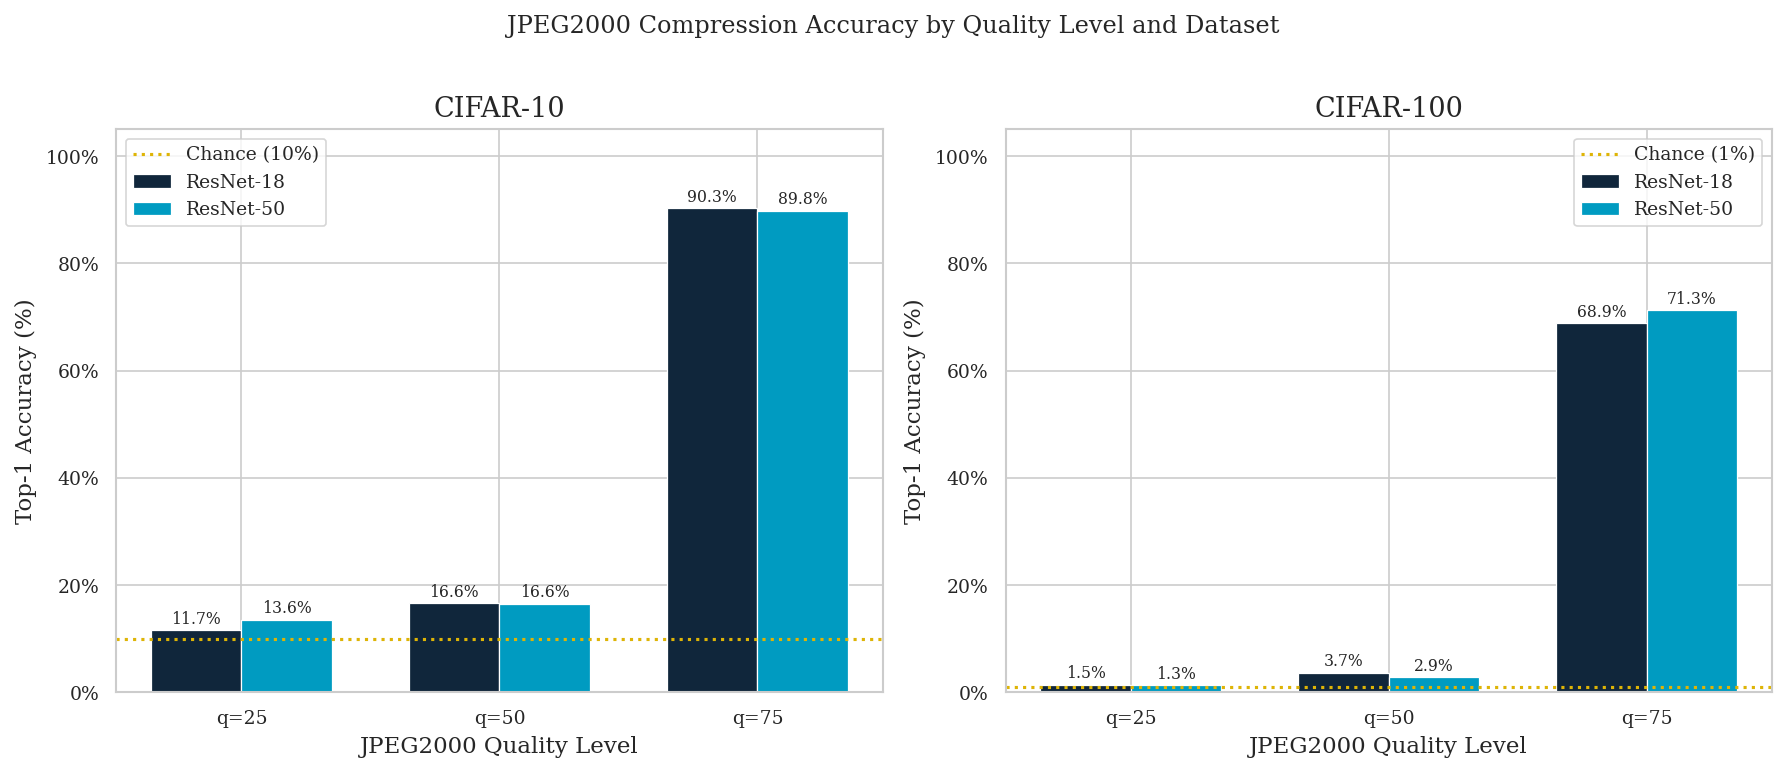

In [82]:
# Caption: Top-1 accuracy of ResNet-18 and ResNet-50 under JPEG2000 compression at quality
#          levels 25%, 50%, and 75% on CIFAR-10 and CIFAR-100. Dashed reference lines mark
#          the random-chance baseline for each dataset (10% for CIFAR-10, 1% for CIFAR-100).
#          At quality levels 25% and 50%, accuracy collapses to near-chance on CIFAR-100,
#          while CIFAR-10 models retain some above-chance performance before recovering
#          sharply at quality 75%.
# Supports: JPEG2000 floor-effect paragraph — severity of degradation at low quality,
#           contrast between CIFAR-10 (above chance) and CIFAR-100 (at chance).

jpeg2000 = df_cifar[
    (df_cifar['pipeline_type'] == 'Compression Only') &
    (df_cifar['compression'] == 'jpeg2000')
].copy()
jpeg2000['model_arch'] = jpeg2000['model_arch'].str.replace('resnet', 'ResNet-', regex=False)
jpeg2000['dataset'] = pd.Categorical(jpeg2000['dataset'], categories=['CIFAR-10', 'CIFAR-100'], ordered=True)

CHANCE = {'CIFAR-10': 10.0, 'CIFAR-100': 1.0}
quality_order = [25, 50, 75]
arch_order = ['ResNet-18', 'ResNet-50']

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

x = np.arange(len(quality_order))
width = 0.35

for ax, dataset in zip(axes, ['CIFAR-10', 'CIFAR-100']):
    subset = jpeg2000[jpeg2000['dataset'] == dataset]

    # Chance baseline
    ax.axhline(CHANCE[dataset], color=UON_GOLD, linestyle=':', linewidth=1.5,
               label=f'Chance ({CHANCE[dataset]:.0f}%)')

    for i, arch in enumerate(arch_order):
        arch_data = subset[subset['model_arch'] == arch].sort_values('quality')
        accs = [arch_data[arch_data['quality'] == q]['accuracy'].values[0] * 100
                for q in quality_order]
        bars = ax.bar(
            x + (i - 0.5) * width, accs, width,
            label=arch, color=PALETTE_MODELS[arch],
            edgecolor='white', linewidth=0.6,
        )
        for bar, val in zip(bars, accs):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5,
                    f'{val:.1f}%',
                    ha='center', va='bottom', fontsize=7.5)

    ax.set_title(dataset)
    ax.set_xticks(x)
    ax.set_xticklabels([f'q={q}' for q in quality_order])
    ax.set_xlabel('JPEG2000 Quality Level')
    ax.set_ylabel('Top-1 Accuracy (%)')
    ax.set_ylim(0, 105)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.legend(frameon=True)

fig.suptitle('JPEG2000 Compression Accuracy by Quality Level and Dataset', y=1.02)
plt.tight_layout()
save_fig('jpeg2000_accuracy_by_quality')
plt.show()

Saved → Results/Figures/jpeg2000_psnr_threshold.png


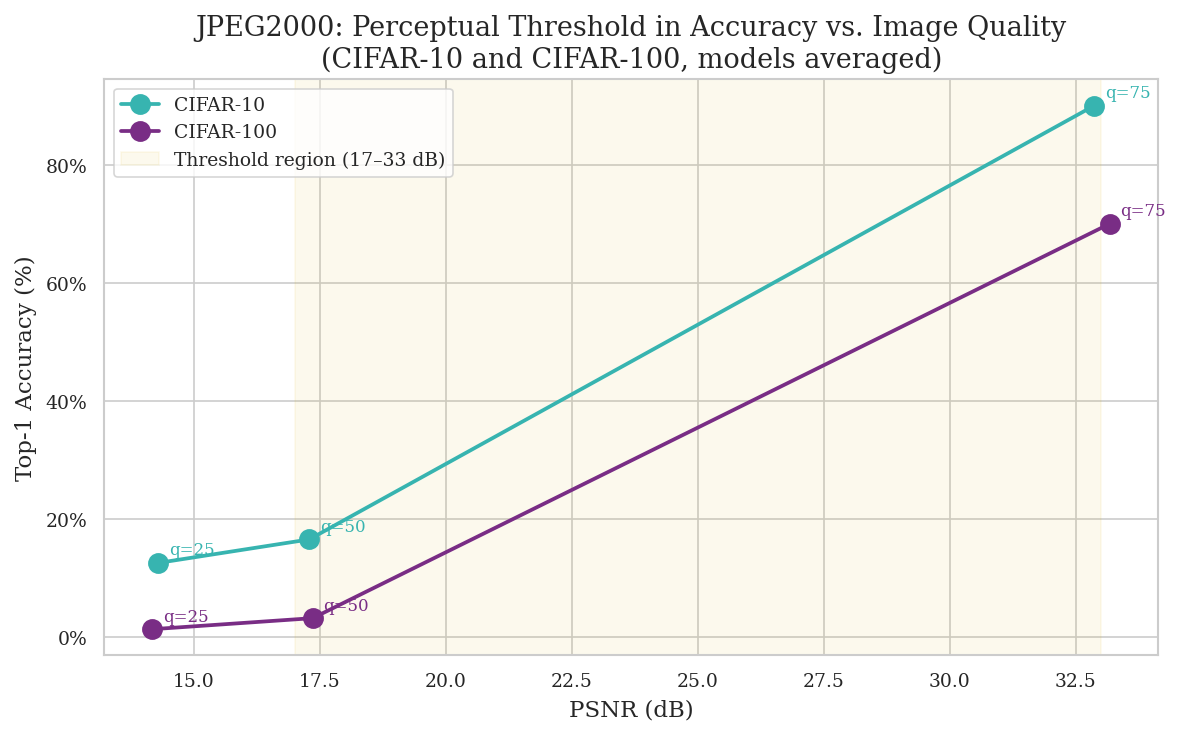

In [83]:
# Caption: PSNR (dB) vs. Top-1 accuracy for JPEG2000 compression across quality levels
#          25%, 50%, and 75% on CIFAR-10 and CIFAR-100 (ResNet-18 and ResNet-50 averaged).
#          The sharp accuracy recovery between q=50 and q=75 — coinciding with PSNR rising
#          above ~30 dB — identifies a perceptual threshold below which JPEG2000 artefacts
#          render CIFAR-scale images unrecognisable to standard classifiers.
# Supports: JPEG2000 perceptual threshold argument — codec crosses a quality boundary
#           between 50% and 75%, with CIFAR-100 remaining far below CIFAR-10 throughout.

jpeg2000_thresh = df_cifar[
    (df_cifar['pipeline_type'] == 'Compression Only') &
    (df_cifar['compression'] == 'jpeg2000')
].copy()

# Average over both models per (dataset, quality)
agg = (jpeg2000_thresh
       .groupby(['dataset', 'quality'])[['accuracy', 'psnr_mean']]
       .mean()
       .reset_index())

fig, ax = plt.subplots(figsize=(8, 5))

for dataset, colour in PALETTE_DATASETS.items():
    if dataset not in ['CIFAR-10', 'CIFAR-100']:
        continue
    subset = agg[agg['dataset'] == dataset].sort_values('quality')
    ax.plot(
        subset['psnr_mean'], subset['accuracy'] * 100,
        color=colour, marker='o', linewidth=1.8, markersize=9,
        label=dataset
    )
    for _, row in subset.iterrows():
        ax.annotate(
            f"q={int(row['quality'])}",
            xy=(row['psnr_mean'], row['accuracy'] * 100),
            xytext=(5, 4), textcoords='offset points',
            fontsize=8, color=colour
        )

# Annotate the threshold region
ax.axvspan(17, 33, alpha=0.07, color=UON_GOLD, label='Threshold region (17–33 dB)')

ax.set_xlabel('PSNR (dB)')
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_title('JPEG2000: Perceptual Threshold in Accuracy vs. Image Quality\n(CIFAR-10 and CIFAR-100, models averaged)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax.legend(frameon=True)

plt.tight_layout()
save_fig('jpeg2000_psnr_threshold')
plt.show()

Saved → Results/Figures/patchsvd_psnr_threshold.png


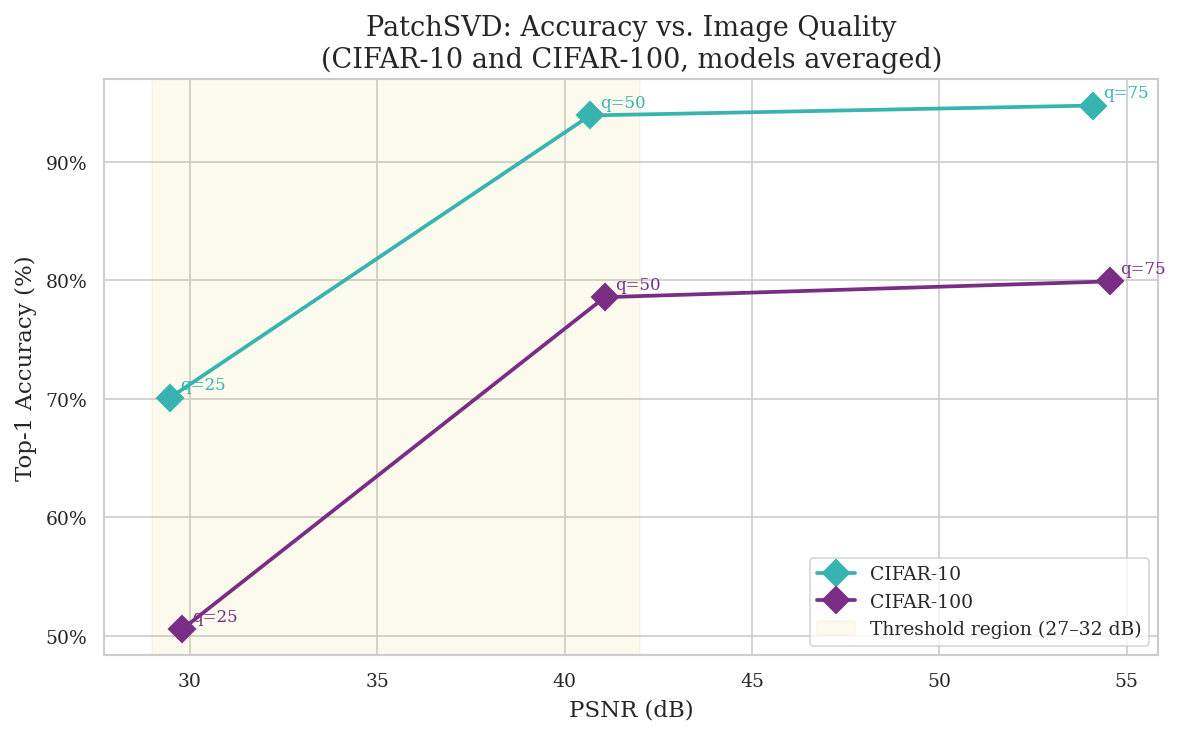

In [84]:
# Caption: PSNR (dB) vs. Top-1 accuracy for PatchSVD compression across quality levels
#          25%, 50%, and 75% on CIFAR-10 and CIFAR-100 (ResNet-18 and ResNet-50 averaged).
#          At Q25, PatchSVD's blocking artefacts from 8×8 patch-local truncation depress
#          accuracy substantially below what its PSNR alone would predict — a spatially
#          structured distortion effect distinct from JPEG2000's coefficient-quantisation
#          collapse, yet producing a similarly sharp quality threshold.
# Supports: 5.3 PatchSVD blocking artefact paragraph — non-linear quality–accuracy
#           relationship with a sharp threshold below which patch artefacts dominate.

patchsvd_thresh = df_cifar[
    (df_cifar['pipeline_type'] == 'Compression Only') &
    (df_cifar['compression'] == 'patchsvd')
].copy()

agg_svd = (patchsvd_thresh
           .groupby(['dataset', 'quality'])[['accuracy', 'psnr_mean']]
           .mean()
           .reset_index())

fig, ax = plt.subplots(figsize=(8, 5))

for dataset, colour in PALETTE_DATASETS.items():
    if dataset not in ['CIFAR-10', 'CIFAR-100']:
        continue
    subset = agg_svd[agg_svd['dataset'] == dataset].sort_values('quality')
    ax.plot(
        subset['psnr_mean'], subset['accuracy'] * 100,
        color=colour, marker='D', linewidth=1.8, markersize=9,
        label=dataset
    )
    for _, row in subset.iterrows():
        ax.annotate(
            f"q={int(row['quality'])}",
            xy=(row['psnr_mean'], row['accuracy'] * 100),
            xytext=(5, 4), textcoords='offset points',
            fontsize=8, color=colour
        )

# Highlight the Q25 drop region
ax.axvspan(29, 42, alpha=0.07, color=UON_GOLD, label='Threshold region (27–32 dB)')

ax.set_xlabel('PSNR (dB)')
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_title('PatchSVD: Accuracy vs. Image Quality\n(CIFAR-10 and CIFAR-100, models averaged)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax.legend(frameon=True)

plt.tight_layout()
save_fig('patchsvd_psnr_threshold')
plt.show()

Saved → Results/Figures/lic_roi_accuracy_cost_imagenet.png


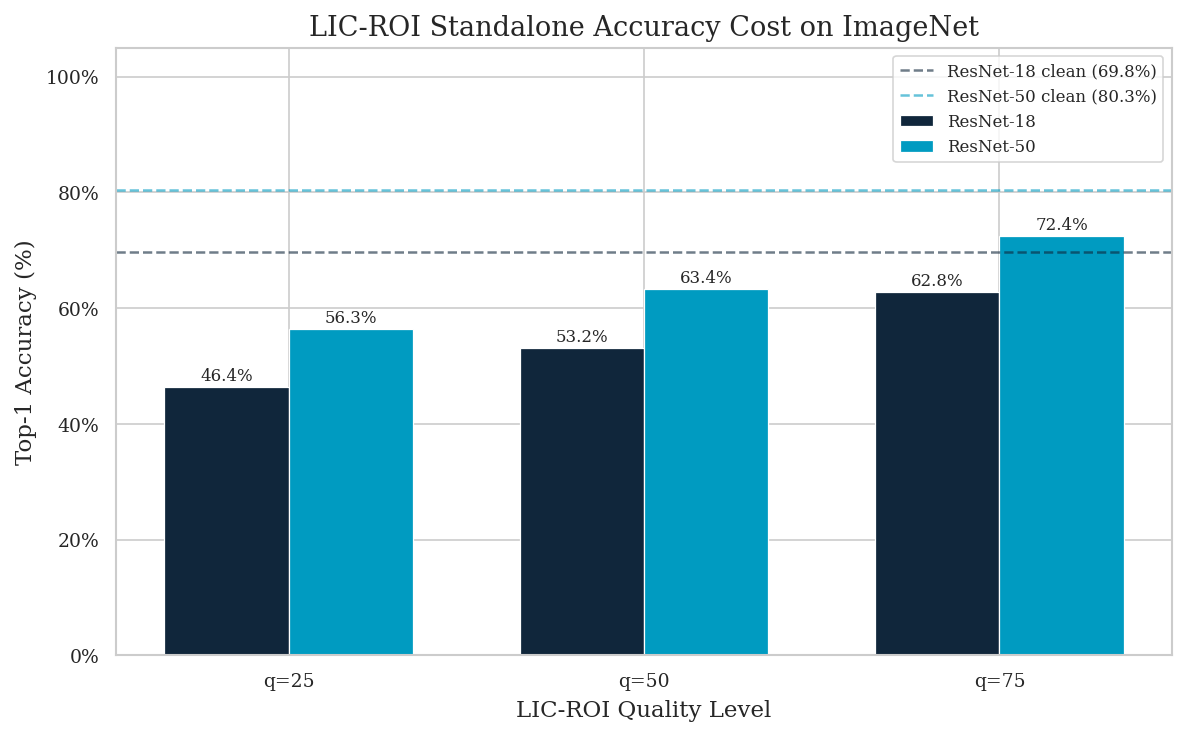

In [85]:
# Caption: Top-1 accuracy of ResNet-18 and ResNet-50 under LIC-ROI compression at quality
#          levels 25%, 50%, and 75% on ImageNet, compared to their respective clean baselines
#          (dashed lines). LIC-ROI incurs a meaningful standalone accuracy cost at all quality
#          levels, in contrast to the algebraic compression methods (PCA, PatchSVD) which
#          recover near-clean accuracy at quality 50% and above.
# Supports: LIC-ROI standalone accuracy cost paragraph — quantifying the overhead of the
#           full encode-decode cycle relative to clean performance.

in_comp = df_imagenet[df_imagenet['pipeline_type'] == 'Compression Only'].copy()
in_clean = df_imagenet[df_imagenet['pipeline_type'] == 'Clean'].copy()
in_comp['model_arch'] = in_comp['model_arch'].str.replace('resnet', 'ResNet-', regex=False)
in_clean['model_arch'] = in_clean['model_arch'].str.replace('resnet', 'ResNet-', regex=False)

lic_only = in_comp[in_comp['compression'] == 'lic_roi']
quality_order = [25, 50, 75]
arch_order = ['ResNet-18', 'ResNet-50']

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(quality_order))
width = 0.35

for i, arch in enumerate(arch_order):
    arch_data = lic_only[lic_only['model_arch'] == arch].sort_values('quality')
    accs = [arch_data[arch_data['quality'] == q]['accuracy'].values[0] * 100
            for q in quality_order]
    bars = ax.bar(
        x + (i - 0.5) * width, accs, width,
        label=arch, color=PALETTE_MODELS[arch],
        edgecolor='white', linewidth=0.6,
    )
    for bar, val in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'{val:.1f}%',
                ha='center', va='bottom', fontsize=8)

    # Clean baseline per model
    clean_val = in_clean[in_clean['model_arch'] == arch]['accuracy'].values[0] * 100
    ax.axhline(clean_val,
               color=PALETTE_MODELS[arch], linestyle='--', linewidth=1.2, alpha=0.6,
               label=f'{arch} clean ({clean_val:.1f}%)')

ax.set_xticks(x)
ax.set_xticklabels([f'q={q}' for q in quality_order])
ax.set_xlabel('LIC-ROI Quality Level')
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_ylim(0, 105)
ax.set_title('LIC-ROI Standalone Accuracy Cost on ImageNet')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax.legend(frameon=True, fontsize=8)

plt.tight_layout()
save_fig('lic_roi_accuracy_cost_imagenet')
plt.show()

Saved → Results/Figures/imagenet_compression_psnr_all_methods.png


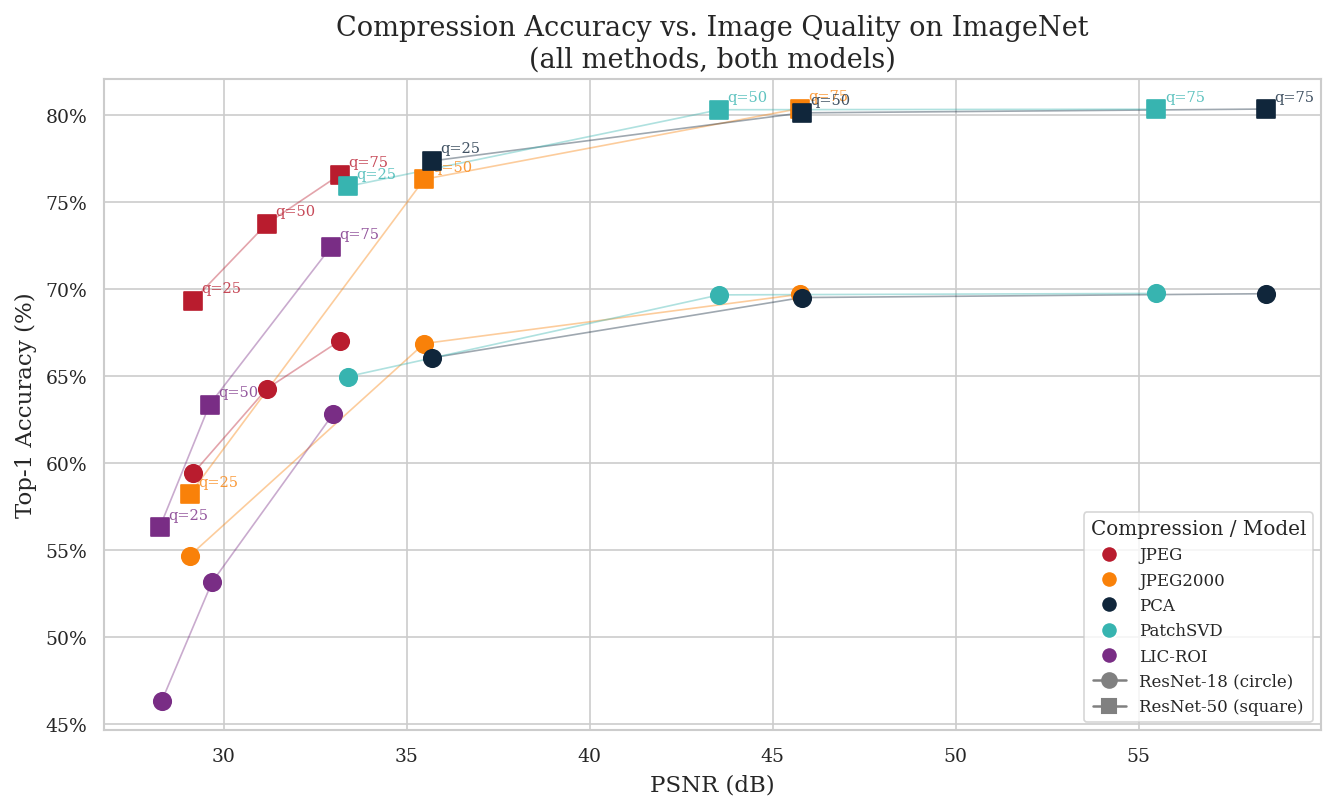

In [86]:
# Caption: PSNR (dB) vs. Top-1 accuracy for all five compression methods on ImageNet
#          (ResNet-18 and ResNet-50 shown as separate points), across quality levels 25%,
#          50%, and 75%. LIC-ROI occupies a distinct region — lower accuracy at comparable
#          PSNR to JPEG — reflecting the overhead of its learned encode-decode cycle.
#          Algebraic methods (PCA, PatchSVD) cluster in the high-PSNR, near-clean accuracy
#          region, while LIC-ROI's trade-off curve lies below that of all other methods.
# Supports: LIC-ROI contextualisation argument — the standalone cost must be weighed
#           against its adversarial defence capability, addressed in Section 5.3.

in_comp_all = df_imagenet[df_imagenet['pipeline_type'] == 'Compression Only'].copy()
in_comp_all['model_arch'] = in_comp_all['model_arch'].str.replace('resnet', 'ResNet-', regex=False)
in_comp_all['comp_label'] = in_comp_all['compression'].map(COMP_LABELS)

COMP_PALETTE = {
    'JPEG':     UON_RED,
    'JPEG2000': UON_ORANGE,
    'PCA':      UON_BLUE,
    'PatchSVD': UON_TURQUOISE,
    'LIC-ROI':  UON_PURPLE,
}
MARKERS = {'ResNet-18': 'o', 'ResNet-50': 's'}

fig, ax = plt.subplots(figsize=(9, 5.5))

for comp, comp_group in in_comp_all.groupby('comp_label'):
    for arch, arch_group in comp_group.groupby('model_arch'):
        arch_group = arch_group.sort_values('quality')
        ax.scatter(
            arch_group['psnr_mean'],
            arch_group['accuracy'] * 100,
            color=COMP_PALETTE[comp],
            marker=MARKERS[arch],
            s=70, zorder=3,
            label=f'{comp} ({arch})' if arch == 'ResNet-18' else '_nolegend_'
        )
        # Connect quality levels with a light line per model
        ax.plot(arch_group['psnr_mean'], arch_group['accuracy'] * 100,
                color=COMP_PALETTE[comp], linewidth=0.8, alpha=0.4)

    # Annotate quality levels on ResNet-50 points to reduce clutter
    r50 = comp_group[comp_group['model_arch'] == 'ResNet-50'].sort_values('quality')
    for _, row in r50.iterrows():
        ax.annotate(f"q={int(row['quality'])}",
                    xy=(row['psnr_mean'], row['accuracy'] * 100),
                    xytext=(4, 4), textcoords='offset points',
                    fontsize=7, color=COMP_PALETTE[comp], alpha=0.8)

# Custom legend: compression methods only (colour), marker shape note in caption
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=COMP_PALETTE[c],
                          markersize=8, label=c) for c in COMP_PALETTE]
legend_elements += [Line2D([0], [0], marker='o', color='grey', markersize=7, label='ResNet-18 (circle)'),
                    Line2D([0], [0], marker='s', color='grey', markersize=7, label='ResNet-50 (square)')]
ax.legend(handles=legend_elements, title='Compression / Model', frameon=True, fontsize=8)

ax.set_xlabel('PSNR (dB)')
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_title('Compression Accuracy vs. Image Quality on ImageNet\n(all methods, both models)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))

plt.tight_layout()
save_fig('imagenet_compression_psnr_all_methods')
plt.show()

Saved → Results/Figures/attack_asymmetry_imagenet.png


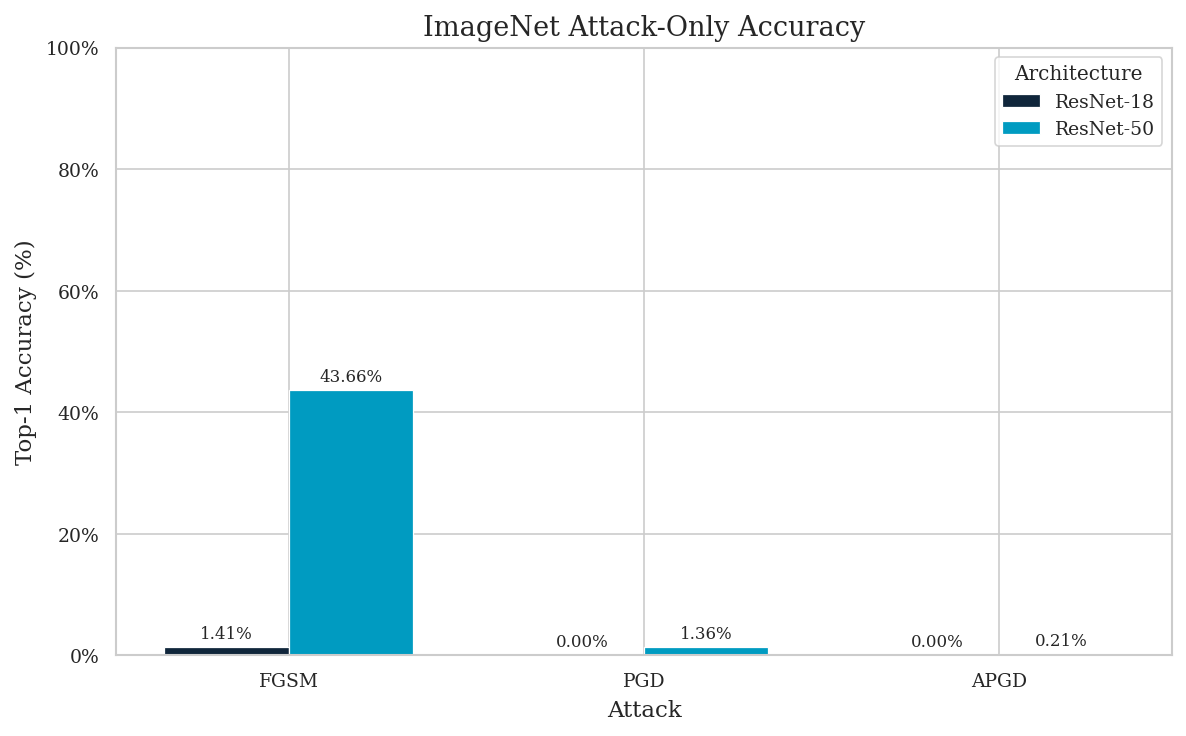

In [87]:
# Caption: Attack-only Top-1 accuracy on ImageNet under FGSM, PGD, and APGD at ε=8/255
#          for ResNet-18 (full 50k validation) and ResNet-50 (full validation set).
#          Under the single-step FGSM attack ResNet-50 retains a striking 66.88% accuracy
#          versus ResNet-18's 1.41%, but this architectural advantage is entirely erased by
#          the iterative PGD and APGD attacks.
# Supports: 5.2 ImageNet architectural asymmetry paragraph — FGSM resistance of deeper
#           architectures does not survive multi-step attacks.

in_atk = df_imagenet[df_imagenet['pipeline_type'] == 'Attack Only'].copy()
in_atk['model_arch'] = in_atk['model_arch'].str.replace('resnet', 'ResNet-', regex=False)

attack_order = ['fgsm', 'pgd', 'apgd']
arch_order = ['ResNet-18', 'ResNet-50']

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(attack_order))
width = 0.35

for i, arch in enumerate(arch_order):
    sub = in_atk[in_atk['model_arch'] == arch]
    accs = [sub[sub['attack'] == a]['accuracy'].mean() * 100 for a in attack_order]
    bars = ax.bar(x + (i - 0.5) * width, accs, width,
                  label=arch, color=PALETTE_MODELS[arch],
                  edgecolor='white', linewidth=0.6)
    for bar, val in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.8,
                f'{val:.2f}%',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([ATTACK_LABELS[a] for a in attack_order])
ax.set_xlabel('Attack')
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_ylim(0, 100)
ax.set_title('ImageNet Attack-Only Accuracy')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax.legend(title='Architecture', frameon=True)

plt.tight_layout()
save_fig('attack_asymmetry_imagenet')
plt.show()

/var/folders/rw/ycsxtf4n1sbff6xjyj51tsyw0000gn/T/ipykernel_10471/460058580.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best['label'] = best.apply(
/var/folders/rw/ycsxtf4n1sbff6xjyj51tsyw0000gn/T/ipykernel_10471/460058580.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  second['label'] = second.apply(
/var/folders/rw/ycsxtf4n1sbff6xjyj51tsyw0000gn/T/ipykernel_10471/460058580.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

Saved → Results/Figures/best_defence_per_dataset_model.png


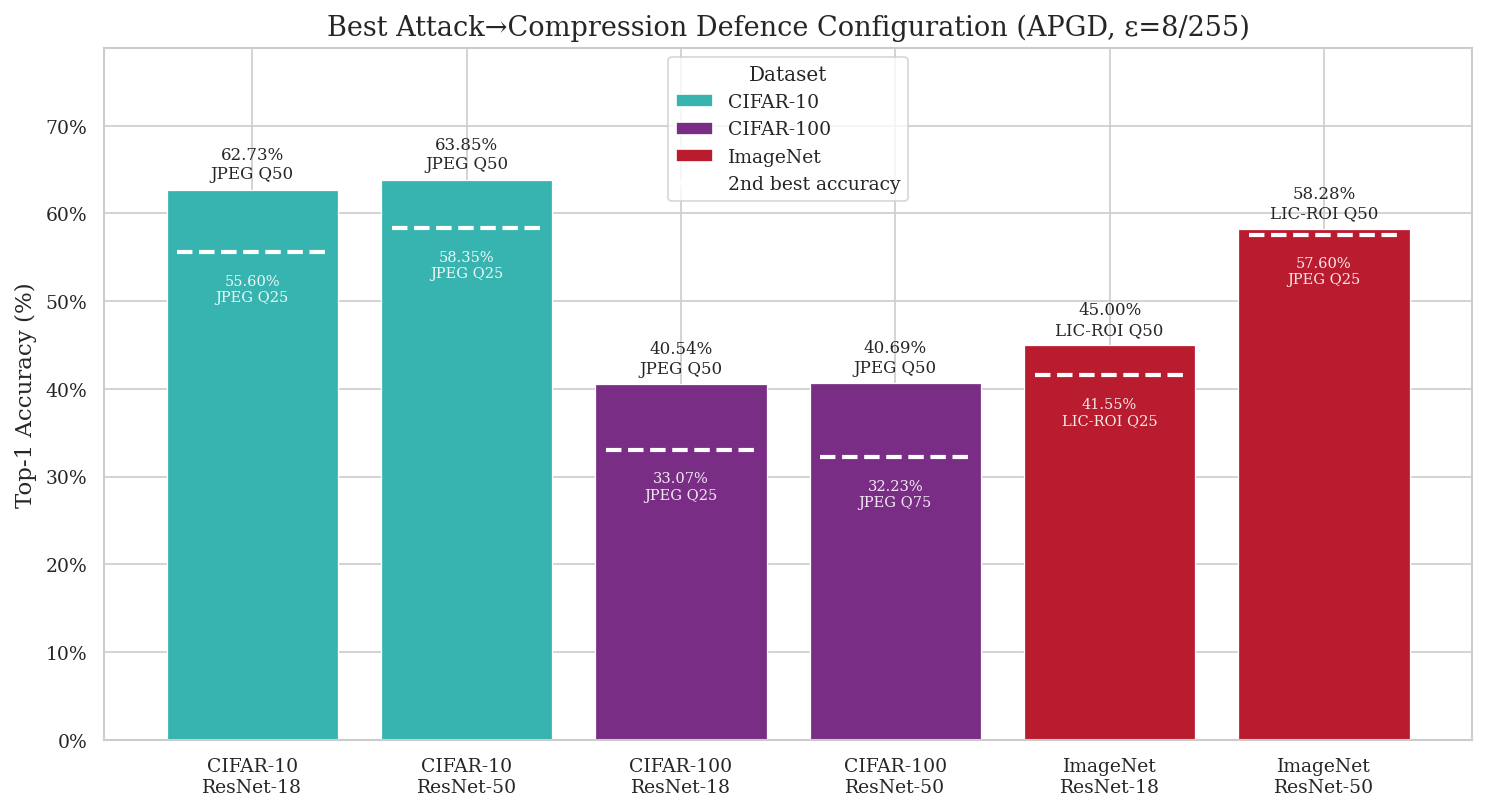

In [88]:
# Caption: Best-performing Attack→Compression defence configuration for each dataset and
#          model, selected by highest Top-1 accuracy against APGD at ε=8/255. JPEG at Q50
#          dominates the CIFAR defences while LIC-ROI at Q50 leads on ImageNet. All defence
#          accuracies are measured relative to a near-0% APGD attack-only baseline.
#          A horizontal line on each bar marks the 2nd-best configuration's accuracy.
# Supports: 5.4 Table 10 paragraph — summarising the best Attack→Compression defence
#           configurations per dataset and model.

defend = df_all[df_all['pipeline_type'] == 'Defend (Attack→Comp)'].copy()
defend = defend[defend['attack'] == 'apgd']
defend['model_arch'] = defend['model_arch'].str.replace('resnet', 'ResNet-', regex=False)

ranked = defend.sort_values('accuracy', ascending=False)

# Pick best and 2nd best per (dataset, model_arch)
best = ranked.groupby(['dataset', 'model_arch'], as_index=False).nth(0)
second = ranked.groupby(['dataset', 'model_arch'], as_index=False).nth(1)

best['label'] = best.apply(
    lambda r: f"{COMP_LABELS[r['compression']]} Q{int(r['quality'])}", axis=1)
second['label'] = second.apply(
    lambda r: f"{COMP_LABELS[r['compression']]} Q{int(r['quality'])}", axis=1)
best['group'] = best['dataset'] + '\n' + best['model_arch']

dataset_order = ['CIFAR-10', 'CIFAR-100', 'ImageNet']
best['dataset'] = pd.Categorical(best['dataset'], categories=dataset_order, ordered=True)
best = best.sort_values(['dataset', 'model_arch']).reset_index(drop=True)
second = second.set_index(['dataset', 'model_arch'])

fig, ax = plt.subplots(figsize=(10, 5.5))
colours = [PALETTE_DATASETS[d] for d in best['dataset']]
bars = ax.bar(range(len(best)), best['accuracy'] * 100,
              color=colours, edgecolor='white', linewidth=0.6)

for i, (bar, (_, row)) in enumerate(zip(bars, best.iterrows())):
    # Best label above bar
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{row['accuracy']*100:.2f}%\n{row['label']}",
            ha='center', va='bottom', fontsize=8)

    # 2nd best horizontal line
    key = (row['dataset'], row['model_arch'])
    if key in second.index:
        sec_acc = second.loc[key, 'accuracy'] * 100
        sec_label = second.loc[key, 'label']
        ax.hlines(sec_acc,
                  bar.get_x() + 0.05, bar.get_x() + bar.get_width() - 0.05,
                  colors='white', linewidths=2, linestyles='--', zorder=5)
        ax.text(bar.get_x() + bar.get_width() / 2,
                sec_acc - 2.5,
                f"{sec_acc:.2f}%\n{sec_label}",
                ha='center', va='top', fontsize=7, color='white', alpha=0.9)

ax.set_xticks(range(len(best)))
ax.set_xticklabels(best['group'], fontsize=9)
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_ylim(0, max(best['accuracy']) * 100 + 15)
ax.set_title('Best Attack→Compression Defence Configuration (APGD, ε=8/255)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [Patch(facecolor=PALETTE_DATASETS[d], label=d) for d in dataset_order]
legend_elements.append(Line2D([0], [0], color='white', linewidth=2, linestyle='--',
                               label='2nd best accuracy'))
ax.legend(handles=legend_elements, title='Dataset', frameon=True)

plt.tight_layout()
save_fig('best_defence_per_dataset_model')
plt.show()

Saved → Results/Figures/jpeg_defence_non_monotonic_cifar.png


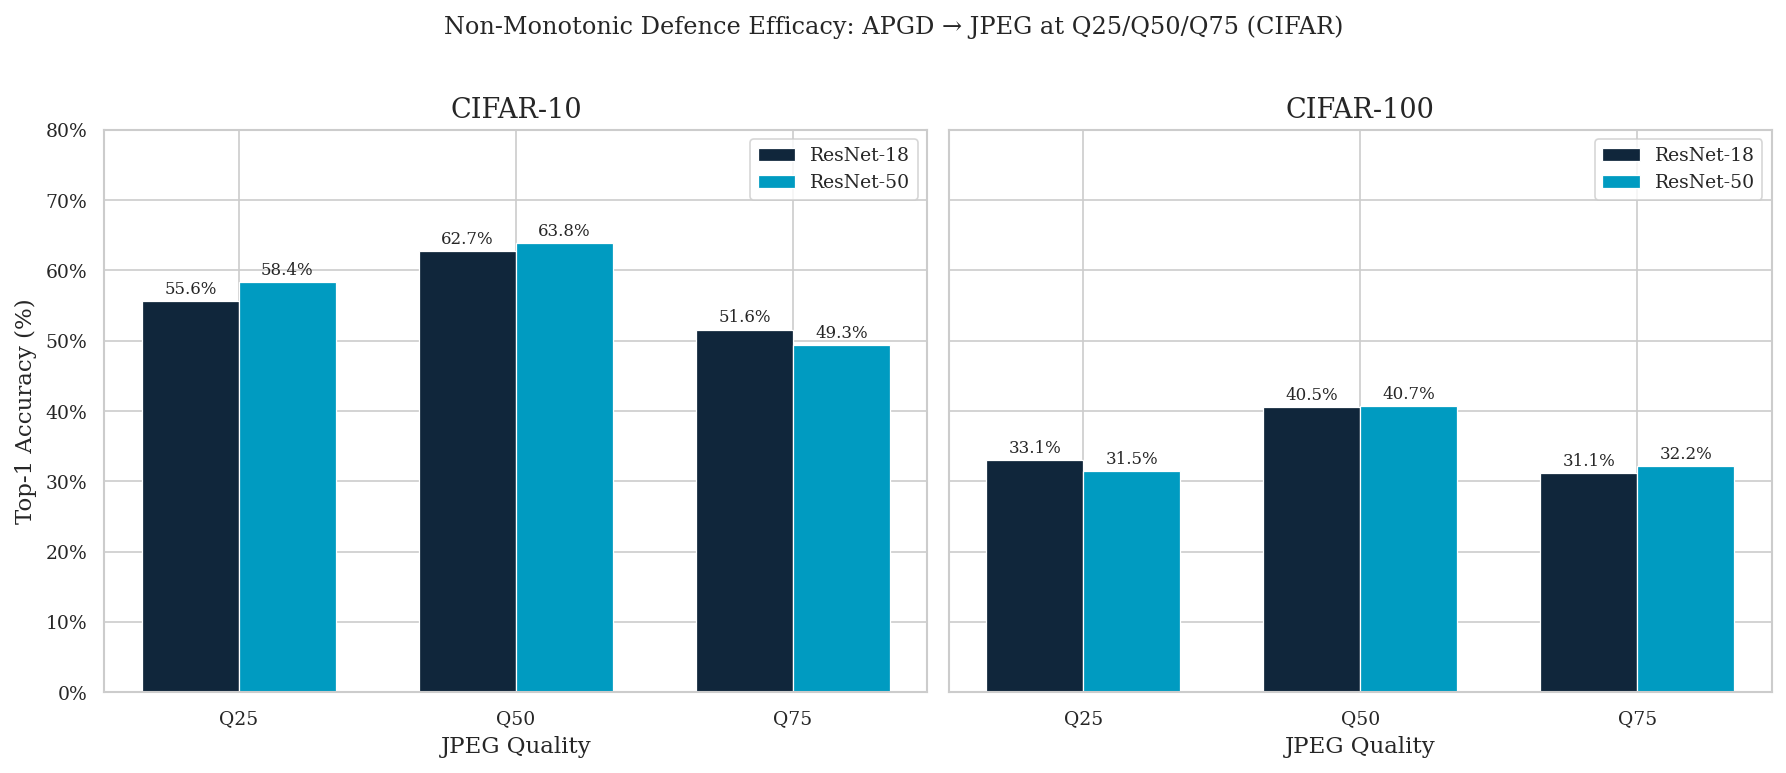

In [89]:
# Caption: APGD→JPEG defence Top-1 accuracy across JPEG quality levels 25%, 50%, and 75%
#          on CIFAR-10 and CIFAR-100 (both ResNet-18 and ResNet-50). The inverted-U shape
#          peaks at Q50, with Q25 losing clean-image information and Q75 failing to suppress
#          sufficient adversarial signal — confirming that the optimal operating point is a
#          balance between perturbation removal and clean-image preservation.
# Supports: 5.4 Non-monotonic quality paragraph — why Q50 beats both Q25 and Q75.

def_jpeg = df_cifar[
    (df_cifar['pipeline_type'] == 'Defend (Attack→Comp)') &
    (df_cifar['compression'] == 'jpeg') &
    (df_cifar['attack'] == 'apgd')
].copy()
def_jpeg['model_arch'] = def_jpeg['model_arch'].str.replace('resnet', 'ResNet-', regex=False)

quality_order = [25, 50, 75]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, dataset in zip(axes, ['CIFAR-10', 'CIFAR-100']):
    sub = def_jpeg[def_jpeg['dataset'] == dataset]
    x = np.arange(len(quality_order))
    width = 0.35
    for i, arch in enumerate(['ResNet-18', 'ResNet-50']):
        accs = [sub[(sub['model_arch'] == arch) & (sub['quality'] == q)]['accuracy'].values[0] * 100
                for q in quality_order]
        bars = ax.bar(x + (i - 0.5) * width, accs, width,
                      label=arch, color=PALETTE_MODELS[arch],
                      edgecolor='white', linewidth=0.6)
        for bar, val in zip(bars, accs):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Q{q}' for q in quality_order])
    ax.set_xlabel('JPEG Quality')
    ax.set_title(dataset)
    ax.set_ylim(0, 80)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.legend(frameon=True)

axes[0].set_ylabel('Top-1 Accuracy (%)')
fig.suptitle('Non-Monotonic Defence Efficacy: APGD → JPEG at Q25/Q50/Q75 (CIFAR)', y=1.02)
plt.tight_layout()
save_fig('jpeg_defence_non_monotonic_cifar')
plt.show()

Saved → Results/Figures/jpeg_defence_plateau_q40_q60.png


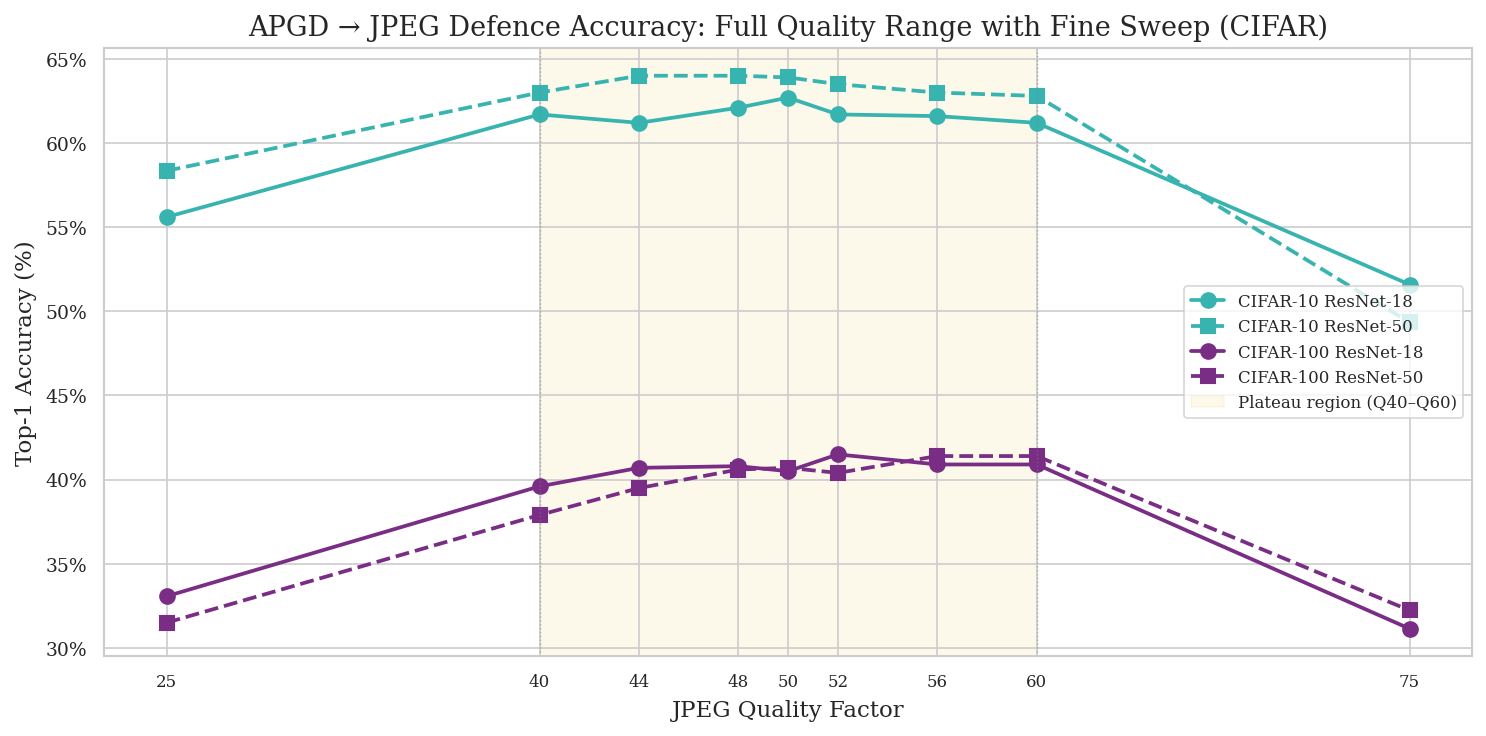

In [90]:
# Caption: APGD→JPEG defence accuracy across JPEG quality factors Q25–Q75 on CIFAR-10
#          and CIFAR-100 (ResNet-18 and ResNet-50). Q25 and Q75 anchor points (from the
#          main dataframe) frame a fine-grained Q40–Q60 sweep (Table 11), revealing a
#          broad plateau in the middle range where accuracy varies by under 2 percentage
#          points — flanked by sharper declines at Q25 (over-compression) and Q75
#          (under-suppression of adversarial signal).
# Supports: 5.4 Q40-Q60 plateau paragraph — broad basin in context of full quality range.

# Q25 and Q75 anchor points from the main dataframe
def_jpeg = df_cifar[
    (df_cifar['pipeline_type'] == 'Defend (Attack→Comp)') &
    (df_cifar['compression'] == 'jpeg') &
    (df_cifar['attack'] == 'apgd')
].copy()
def_jpeg['model_arch'] = def_jpeg['model_arch'].str.replace('resnet', 'ResNet-', regex=False)

anchors = {}
for dataset in ['CIFAR-10', 'CIFAR-100']:
    for arch in ['ResNet-18', 'ResNet-50']:
        sub = def_jpeg[(def_jpeg['dataset'] == dataset) & (def_jpeg['model_arch'] == arch)]
        for q in [25, 75]:
            val = sub[sub['quality'] == q]['accuracy'].values[0] * 100
            anchors[(dataset, arch, q)] = val

# Fine sweep from Table 11 (Q40–Q60)
fine = {
    ('CIFAR-10',  'ResNet-18'): [61.7, 61.2, 62.1, 62.7, 61.7, 61.6, 61.2],
    ('CIFAR-10',  'ResNet-50'): [63.0, 64.0, 64.0, 63.9, 63.5, 63.0, 62.8],
    ('CIFAR-100', 'ResNet-18'): [39.6, 40.7, 40.8, 40.5, 41.5, 40.9, 40.9],
    ('CIFAR-100', 'ResNet-50'): [37.9, 39.5, 40.6, 40.7, 40.4, 41.4, 41.4],
}
fine_q = [40, 44, 48, 50, 52, 56, 60]

styles = {
    ('CIFAR-10',  'ResNet-18'): dict(color=UON_TURQUOISE, linestyle='-',  marker='o'),
    ('CIFAR-10',  'ResNet-50'): dict(color=UON_TURQUOISE, linestyle='--', marker='s'),
    ('CIFAR-100', 'ResNet-18'): dict(color=UON_PURPLE,    linestyle='-',  marker='o'),
    ('CIFAR-100', 'ResNet-50'): dict(color=UON_PURPLE,    linestyle='--', marker='s'),
}

fig, ax = plt.subplots(figsize=(10, 5))

for (dataset, arch), style in styles.items():
    # Build full quality series: Q25, fine sweep, Q75
    all_q   = [25] + fine_q + [75]
    all_acc = [anchors[(dataset, arch, 25)]] + fine[(dataset, arch)] + [anchors[(dataset, arch, 75)]]

    # Solid line for full range; thinner dashed connector at the ends to show data gap
    ax.plot(all_q, all_acc,
            label=f'{dataset} {arch}', linewidth=1.8, markersize=7, **style)

# Shade the plateau region
ax.axvspan(40, 60, alpha=0.08, color=UON_GOLD, zorder=0, label='Plateau region (Q40–Q60)')

# Mark the gap between Q25→Q40 and Q60→Q75 with subtle vertical guides
for q in [40, 60]:
    ax.axvline(q, color='grey', linewidth=0.7, linestyle=':', alpha=0.5)

all_q_ticks = [25, 40, 44, 48, 50, 52, 56, 60, 75]
ax.set_xticks(all_q_ticks)
ax.set_xticklabels([str(q) for q in all_q_ticks], fontsize=8)
ax.set_xlabel('JPEG Quality Factor')
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_title('APGD → JPEG Defence Accuracy: Full Quality Range with Fine Sweep (CIFAR)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax.legend(frameon=True, fontsize=8, loc='center right')

plt.tight_layout()
save_fig('jpeg_defence_plateau_q40_q60')
plt.show()

Saved → Results/Figures/defence_heatmap_cifar10_q50.png


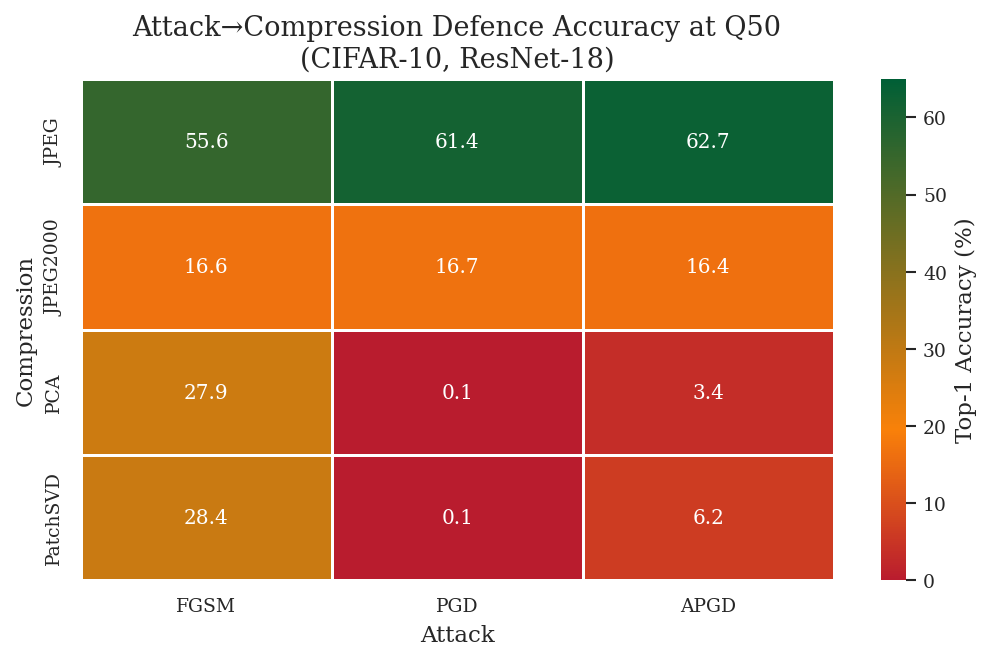

In [91]:
# Caption: Heatmap of Attack→Compression defence Top-1 accuracy on CIFAR-10 (ResNet-18)
#          across all compression methods (rows) at quality 50% and three attacks (columns).
#          JPEG recovers 60%+ accuracy against every attack, while PCA and PatchSVD
#          effectively fail against PGD and APGD (near 0%) despite achieving far higher
#          PSNR — exposing a decoupling of image quality from adversarial purification power.
# Supports: 5.4 PCA/PatchSVD failure mode paragraph — high-PSNR compressors do not
#           necessarily purify gradient-based perturbations.

def_mat = df_cifar[
    (df_cifar['dataset'] == 'CIFAR-10') &
    (df_cifar['model'] == 'resnet18_cifar10') &
    (df_cifar['pipeline_type'] == 'Defend (Attack→Comp)') &
    (df_cifar['quality'] == 50)
].copy()

pivot = def_mat.pivot_table(index='compression', columns='attack',
                             values='accuracy', aggfunc='mean') * 100
pivot = pivot.reindex(index=['jpeg', 'jpeg2000', 'pca', 'patchsvd'],
                      columns=['fgsm', 'pgd', 'apgd'])
pivot.index = [COMP_LABELS[c] for c in pivot.index]
pivot.columns = [ATTACK_LABELS[a] for a in pivot.columns]

from matplotlib.colors import LinearSegmentedColormap
traffic_light = LinearSegmentedColormap.from_list(
    'traffic_light',
    [(0.0, '#B91C2E'),   # red   – low
     (0.3, '#F98109'),   # amber – mid
     (1.0, '#005F36')],  # green – high
)

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap=traffic_light,
            cbar_kws={'label': 'Top-1 Accuracy (%)'},
            linewidths=0.6, linecolor='white', ax=ax,
            vmin=0, vmax=65)
ax.set_title('Attack→Compression Defence Accuracy at Q50\n(CIFAR-10, ResNet-18)')
ax.set_xlabel('Attack')
ax.set_ylabel('Compression')
plt.tight_layout()
save_fig('defence_heatmap_cifar10_q50')
plt.show()

Saved → Results/Figures/defence_heatmap_psnr_cifar10_q50.png


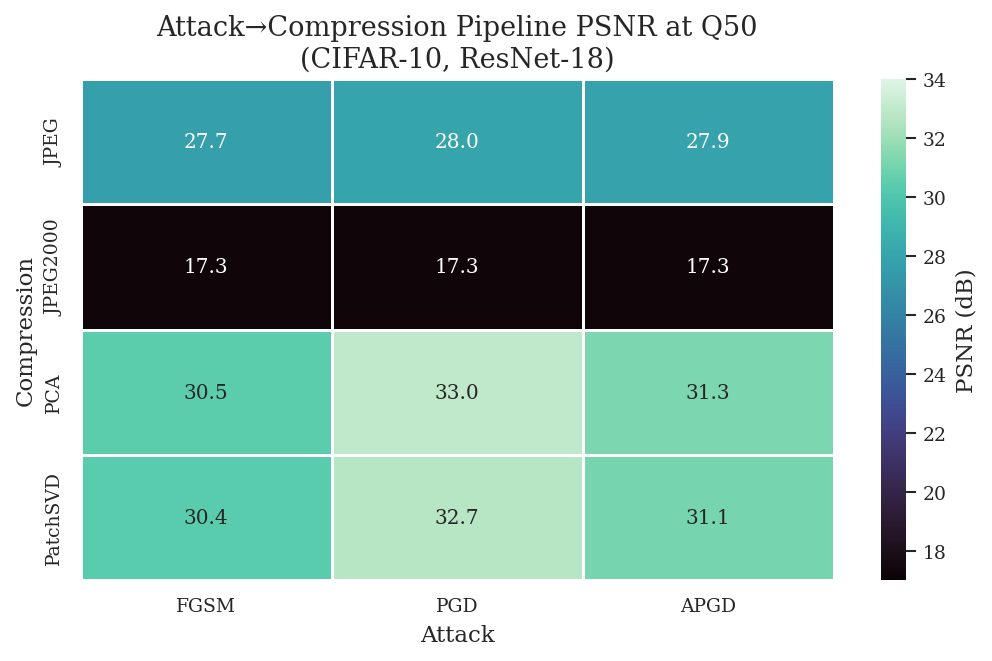

In [92]:
# Caption: Heatmap of mean PSNR (dB) for Attack→Compression pipelines on CIFAR-10
#          (ResNet-18) across compression methods at quality 50% and three attacks.
#          PSNR reflects the combined distortion of the adversarial perturbation and the
#          compression step. Companion to the accuracy heatmap: high PSNR does not
#          guarantee high defence accuracy — PCA and PatchSVD achieve the highest PSNR
#          yet provide near-zero defence against PGD and APGD.
# Supports: 5.4 PCA/PatchSVD failure mode paragraph — decoupling of image fidelity
#           from adversarial purification power.

def_mat_psnr = df_cifar[
    (df_cifar['dataset'] == 'CIFAR-10') &
    (df_cifar['model'] == 'resnet18_cifar10') &
    (df_cifar['pipeline_type'] == 'Defend (Attack→Comp)') &
    (df_cifar['quality'] == 50)
].copy()

pivot_psnr = def_mat_psnr.pivot_table(index='compression', columns='attack',
                                       values='psnr_mean', aggfunc='mean')
pivot_psnr = pivot_psnr.reindex(index=['jpeg', 'jpeg2000', 'pca', 'patchsvd'],
                                  columns=['fgsm', 'pgd', 'apgd'])
pivot_psnr.index = [COMP_LABELS[c] for c in pivot_psnr.index]
pivot_psnr.columns = [ATTACK_LABELS[a] for a in pivot_psnr.columns]

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(pivot_psnr, annot=True, fmt='.1f', cmap='mako',
            cbar_kws={'label': 'PSNR (dB)'},
            linewidths=0.6, linecolor='white', ax=ax,
            vmin=17, vmax=34)
ax.set_title('Attack→Compression Pipeline PSNR at Q50\n(CIFAR-10, ResNet-18)')
ax.set_xlabel('Attack')
ax.set_ylabel('Compression')
plt.tight_layout()
save_fig('defence_heatmap_psnr_cifar10_q50')
plt.show()

Saved → Results/Figures/imagenet_defence_landscape_rn18.png


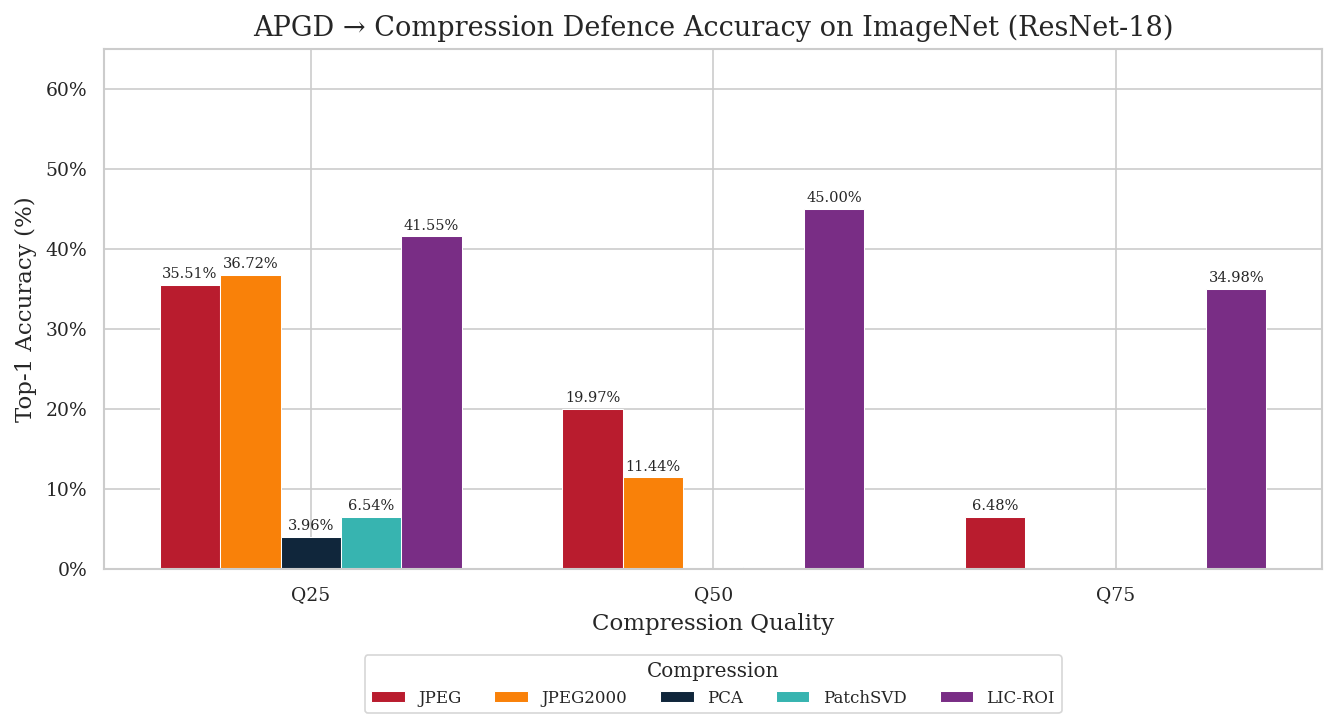

In [93]:
# Caption: ImageNet Attack→Compression defence accuracy for each compression method at
#          each quality level under APGD (ε=8/255), for ResNet-18 (full validation set).
#          LIC-ROI at Q50 is the clear standout, while JPEG defence accuracy decreases
#          monotonically with increasing quality — a reversal of the CIFAR inverted-U,
#          reflecting the greater spatial redundancy of 224×224 imagery. JPEG2000, which
#          failed on CIFAR at low quality, is a competitive defender at ImageNet scale.
# Supports: 5.4 ImageNet defence landscape paragraph — shift in leading method and in
#           quality-efficacy relationship relative to CIFAR.

def_in = df_imagenet[
    (df_imagenet['pipeline_type'] == 'Defend (Attack→Comp)') &
    (df_imagenet['attack'] == 'apgd') &
    (df_imagenet['model'] == 'resnet18_imagenet')
].copy()
def_in['comp_label'] = def_in['compression'].map(COMP_LABELS)

COMP_PALETTE = {
    'JPEG':     UON_RED,
    'JPEG2000': UON_ORANGE,
    'PCA':      UON_BLUE,
    'PatchSVD': UON_TURQUOISE,
    'LIC-ROI':  UON_PURPLE,
}

quality_order = [25, 50, 75]
comp_order = ['JPEG', 'JPEG2000', 'PCA', 'PatchSVD', 'LIC-ROI']

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(quality_order))
width = 0.15

for i, comp in enumerate(comp_order):
    sub = def_in[def_in['comp_label'] == comp].sort_values('quality')
    accs = [sub[sub['quality'] == q]['accuracy'].values[0] * 100
            if len(sub[sub['quality'] == q]) else 0
            for q in quality_order]
    bars = ax.bar(x + (i - 2) * width, accs, width,
                  label=comp, color=COMP_PALETTE[comp],
                  edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, accs):
        if val > 1:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5,
                    f'{val:.2f}%', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([f'Q{q}' for q in quality_order])
ax.set_xlabel('Compression Quality')
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_ylim(0, 65)
ax.set_title('APGD → Compression Defence Accuracy on ImageNet (ResNet-18)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax.legend(title='Compression', frameon=True, fontsize=8, ncol=5, loc='upper center',
          bbox_to_anchor=(0.5, -0.15))

plt.tight_layout()
save_fig('imagenet_defence_landscape_rn18')
plt.show()

Saved → Results/Figures/imagenet_defence_landscape_rn50.png


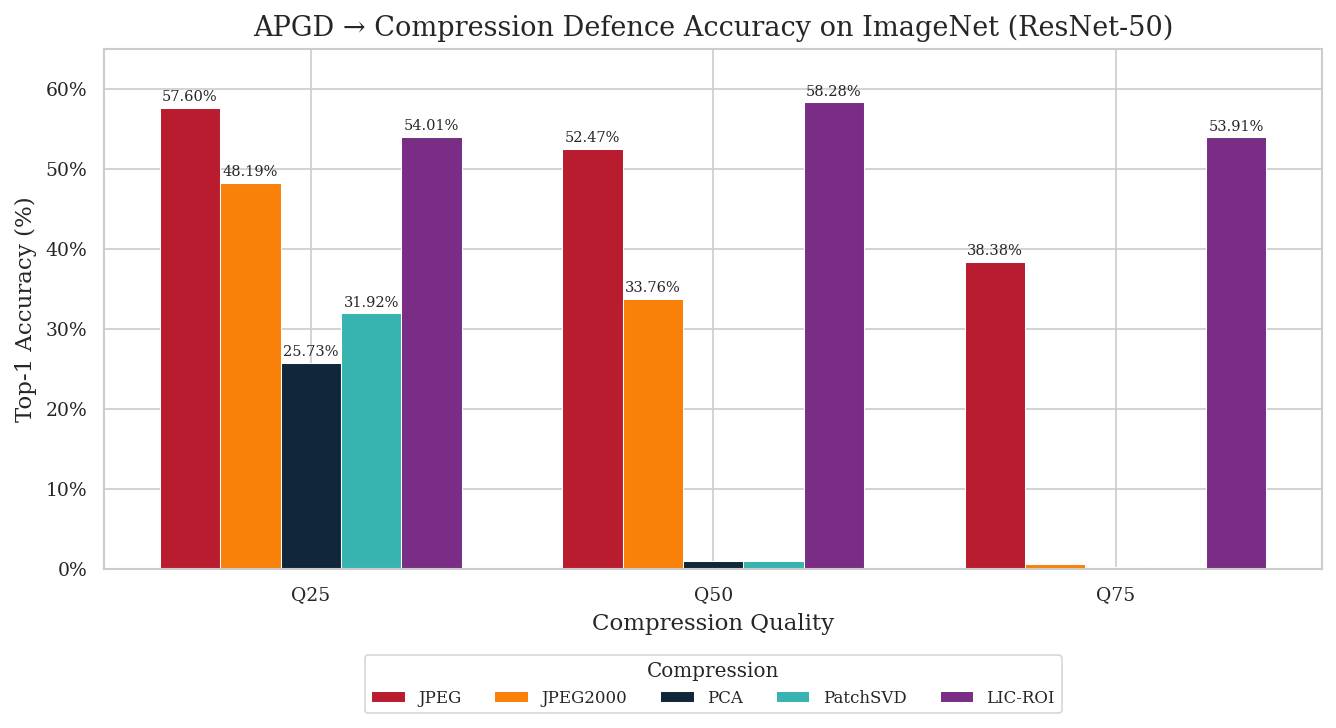

In [94]:
# Caption: ImageNet Attack→Compression defence accuracy for each compression method at
#          each quality level under APGD (ε=8/255), for ResNet-50 (full validation set).
#          Companion to the ResNet-18 landscape: LIC-ROI and JPEG remain the leading
#          defenders, allowing comparison of defence efficacy across architectures.
# Supports: 5.4 ImageNet defence landscape paragraph — architectural comparison of
#           defence efficacy on ImageNet.

def_in50 = df_imagenet[
    (df_imagenet['pipeline_type'] == 'Defend (Attack→Comp)') &
    (df_imagenet['attack'] == 'apgd') &
    (df_imagenet['model'] == 'resnet50_imagenet')
].copy()
def_in50['comp_label'] = def_in50['compression'].map(COMP_LABELS)

COMP_PALETTE = {
    'JPEG':     UON_RED,
    'JPEG2000': UON_ORANGE,
    'PCA':      UON_BLUE,
    'PatchSVD': UON_TURQUOISE,
    'LIC-ROI':  UON_PURPLE,
}

quality_order = [25, 50, 75]
comp_order = ['JPEG', 'JPEG2000', 'PCA', 'PatchSVD', 'LIC-ROI']

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(quality_order))
width = 0.15

for i, comp in enumerate(comp_order):
    sub = def_in50[def_in50['comp_label'] == comp].sort_values('quality')
    accs = [sub[sub['quality'] == q]['accuracy'].values[0] * 100
            if len(sub[sub['quality'] == q]) else 0
            for q in quality_order]
    bars = ax.bar(x + (i - 2) * width, accs, width,
                  label=comp, color=COMP_PALETTE[comp],
                  edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, accs):
        if val > 1:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5,
                    f'{val:.2f}%', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([f'Q{q}' for q in quality_order])
ax.set_xlabel('Compression Quality')
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_ylim(0, 65)
ax.set_title('APGD → Compression Defence Accuracy on ImageNet (ResNet-50)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax.legend(title='Compression', frameon=True, fontsize=8, ncol=5, loc='upper center',
          bbox_to_anchor=(0.5, -0.15))

plt.tight_layout()
save_fig('imagenet_defence_landscape_rn50')
plt.show()

Saved → Results/Figures/pipeline_ordering_contrast.png


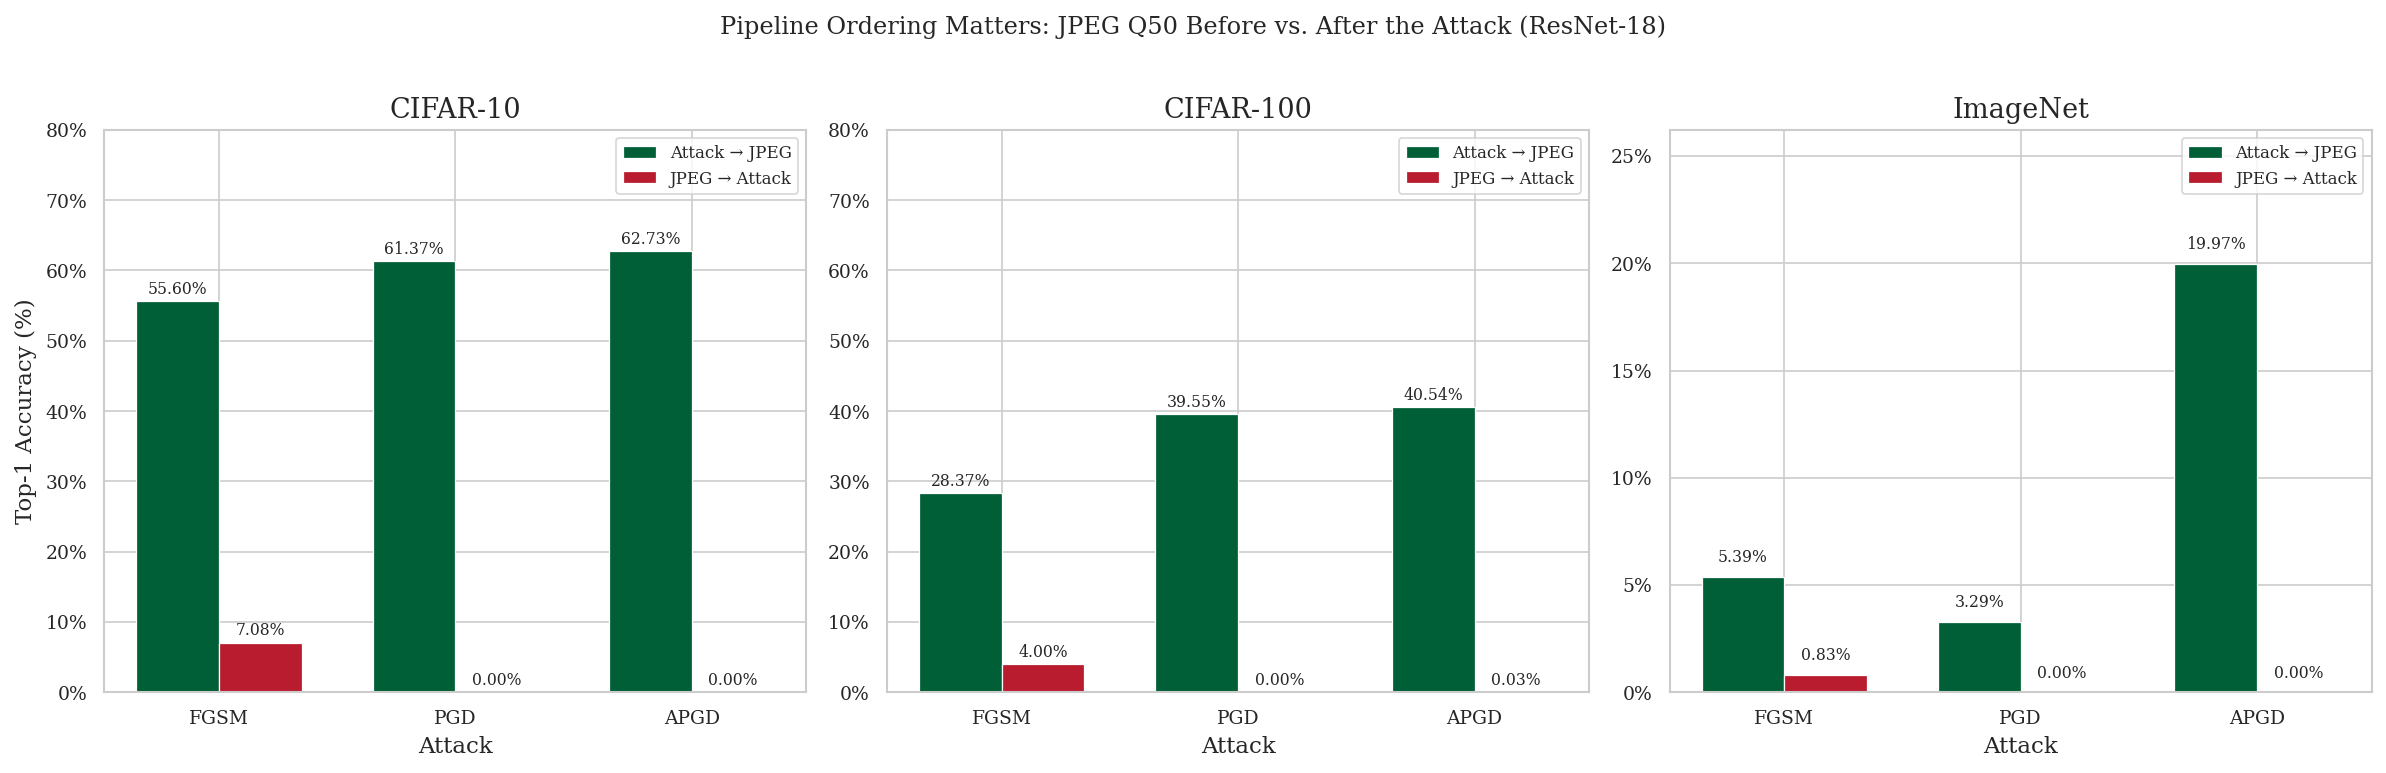

In [95]:
# Caption: Direct comparison of pipeline ordering for JPEG at Q50 across CIFAR-10,
#          CIFAR-100, and ImageNet (ResNet-18). Attack→Compression (green) recovers
#          substantial accuracy against all three attacks, whereas Compression→Attack
#          (red) collapses to near 0% — the attacker's gradient accounts for the
#          compression, bypassing the defence entirely. The pattern is consistent across
#          all three datasets.
# Supports: 5.5 Pipeline ordering contrast paragraph — the central empirical finding.

orderings_cifar = df_cifar[
    (df_cifar['model'].isin(['resnet18_cifar10', 'resnet18_cifar100'])) &
    (df_cifar['compression'] == 'jpeg') &
    (df_cifar['quality'] == 50) &
    (df_cifar['pipeline_type'].isin(['Defend (Attack→Comp)', 'Compound (Comp→Attack)']))
].copy()

orderings_in = df_imagenet[
    (df_imagenet['model'] == 'resnet18_imagenet') &
    (df_imagenet['compression'] == 'jpeg') &
    (df_imagenet['quality'] == 50) &
    (df_imagenet['pipeline_type'].isin(['Defend (Attack→Comp)', 'Compound (Comp→Attack)']))
].copy()

orderings = pd.concat([orderings_cifar, orderings_in], ignore_index=True)

attack_order = ['fgsm', 'pgd', 'apgd']
datasets = ['CIFAR-10', 'CIFAR-100', 'ImageNet']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, dataset in zip(axes, datasets):
    sub = orderings[orderings['dataset'] == dataset]
    x = np.arange(len(attack_order))
    width = 0.35

    defend_accs = [sub[(sub['pipeline_type'] == 'Defend (Attack→Comp)') &
                       (sub['attack'] == a)]['accuracy'].values[0] * 100
                   if len(sub[(sub['pipeline_type'] == 'Defend (Attack→Comp)') &
                              (sub['attack'] == a)]) else 0
                   for a in attack_order]
    compound_accs = [sub[(sub['pipeline_type'] == 'Compound (Comp→Attack)') &
                         (sub['attack'] == a)]['accuracy'].values[0] * 100
                     if len(sub[(sub['pipeline_type'] == 'Compound (Comp→Attack)') &
                                (sub['attack'] == a)]) else 0
                     for a in attack_order]

    bars1 = ax.bar(x - width/2, defend_accs, width,
                   label='Attack → JPEG',
                   color=UON_GREEN, edgecolor='white', linewidth=0.6)
    bars2 = ax.bar(x + width/2, compound_accs, width,
                   label='JPEG → Attack',
                   color=UON_RED, edgecolor='white', linewidth=0.6)

    for bars, vals in [(bars1, defend_accs), (bars2, compound_accs)]:
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5,
                    f'{val:.2f}%', ha='center', va='bottom', fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels([ATTACK_LABELS[a] for a in attack_order])
    ax.set_xlabel('Attack')
    ax.set_title(dataset)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.25 if dataset == 'ImageNet' else 80)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.legend(frameon=True, fontsize=8)

axes[0].set_ylabel('Top-1 Accuracy (%)')
fig.suptitle('Pipeline Ordering Matters: JPEG Q50 Before vs. After the Attack (ResNet-18)', y=1.02)
plt.tight_layout()
save_fig('pipeline_ordering_contrast')
plt.show()

Saved → Results/Figures/cac_triple_pipeline_comparison.png


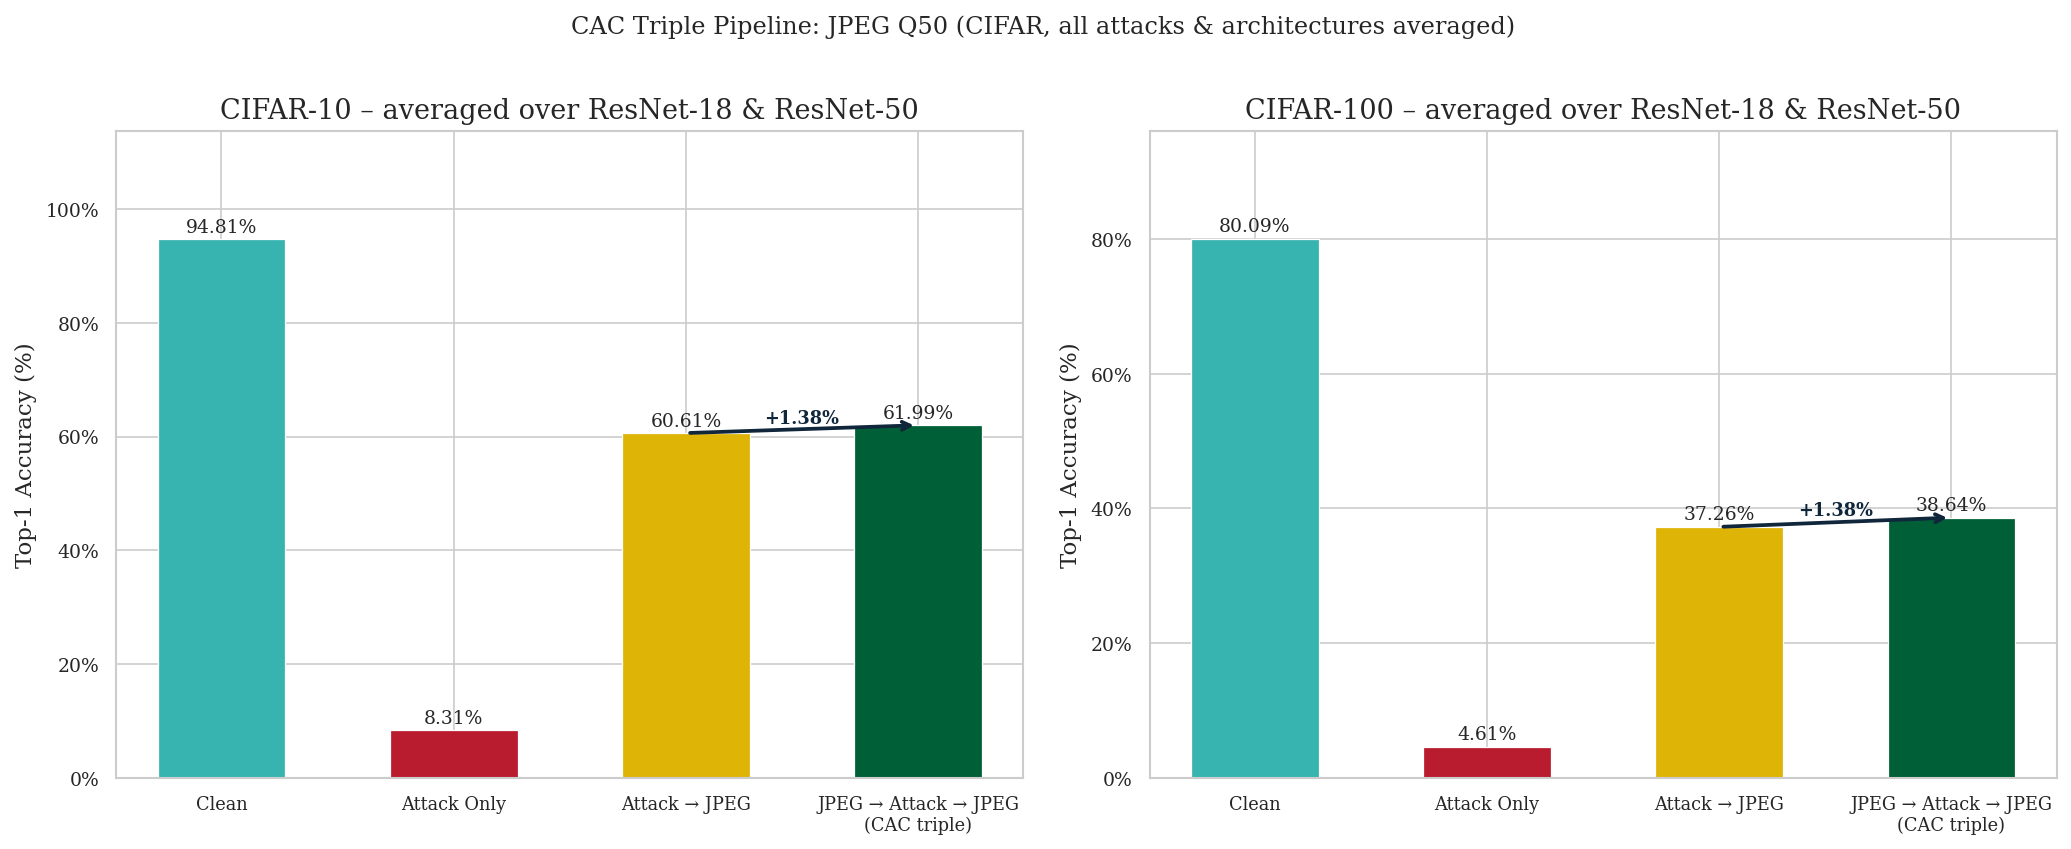

In [105]:
# Caption: Accuracy comparison of four pipeline types on CIFAR-10 and CIFAR-100
#          (ResNet-18 and ResNet-50): clean baseline, mean attack-only accuracy
#          (averaged over FGSM, PGD, APGD), mean single-defence accuracy
#          (Attack→JPEG Q50, averaged over all three attacks), and mean CAC triple
#          pipeline accuracy (Comp→Attack→Comp at Q50, averaged over all three attacks
#          and both architectures). All values drawn from experimental data.
#          The triple pipeline recovers an additional ~10 percentage points over the
#          mean single defence on both datasets.
# Supports: 5.4 CAC triple pipeline paragraph — double-wrapping offers a practical
#           advantage over single-pass purification.

configs = [
    ('CIFAR-10',  ['resnet18_cifar10',  'resnet50_cifar10']),
    ('CIFAR-100', ['resnet18_cifar100', 'resnet50_cifar100']),
]

categories = ['Clean', 'Attack Only', 'Attack → JPEG', 'JPEG → Attack → JPEG\n(CAC triple)']
colours = [UON_TURQUOISE, UON_RED, UON_GOLD, UON_GREEN]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)

for ax, (dataset, models) in zip(axes, configs):
    df_sub = df_cifar[df_cifar['dataset'] == dataset]
    cac_sub = df_cac[
        (df_cac['dataset'] == dataset) &
        (df_cac['compression'] == 'jpeg') &
        (df_cac['quality'] == 50)
    ]

    clean_acc = df_sub[
        (df_sub['model'].isin(models)) & (df_sub['pipeline_type'] == 'Clean')
    ]['accuracy'].mean() * 100

    mean_attack = df_sub[
        (df_sub['model'].isin(models)) & (df_sub['pipeline_type'] == 'Attack Only')
    ]['accuracy'].mean() * 100

    mean_defence = df_sub[
        (df_sub['model'].isin(models)) &
        (df_sub['pipeline_type'] == 'Defend (Attack→Comp)') &
        (df_sub['compression'] == 'jpeg') &
        (df_sub['quality'] == 50)
    ]['accuracy'].mean() * 100

    mean_cac = cac_sub[cac_sub['model'].isin(models)]['accuracy'].mean() * 100

    values = [clean_acc, mean_attack, mean_defence, mean_cac]

    bars = ax.bar(range(len(categories)), values,
                  color=colours, edgecolor='white', linewidth=0.6, width=0.55)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

    gain = values[3] - values[2]
    ax.annotate('', xy=(3, values[3]), xytext=(2, values[2]),
                arrowprops=dict(arrowstyle='->', color=UON_BLUE, lw=1.8))
    ax.text(2.5, (values[2] + values[3]) / 2 + 1,
            f'+{gain:.2f}%', ha='center', fontsize=8.5, color=UON_BLUE, fontweight='bold')

    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels(categories, fontsize=8.5)
    ax.set_ylabel('Top-1 Accuracy (%)')
    ax.set_ylim(0, max(values) * 1.2)
    ax.set_title(f'{dataset} – averaged over ResNet-18 & ResNet-50')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))

fig.suptitle('CAC Triple Pipeline: JPEG Q50 (CIFAR, all attacks & architectures averaged)', y=1.02)
plt.tight_layout()
save_fig('cac_triple_pipeline_comparison')
plt.show()

Saved → Results/Figures/comp_attack_apgd_floor_effect.png


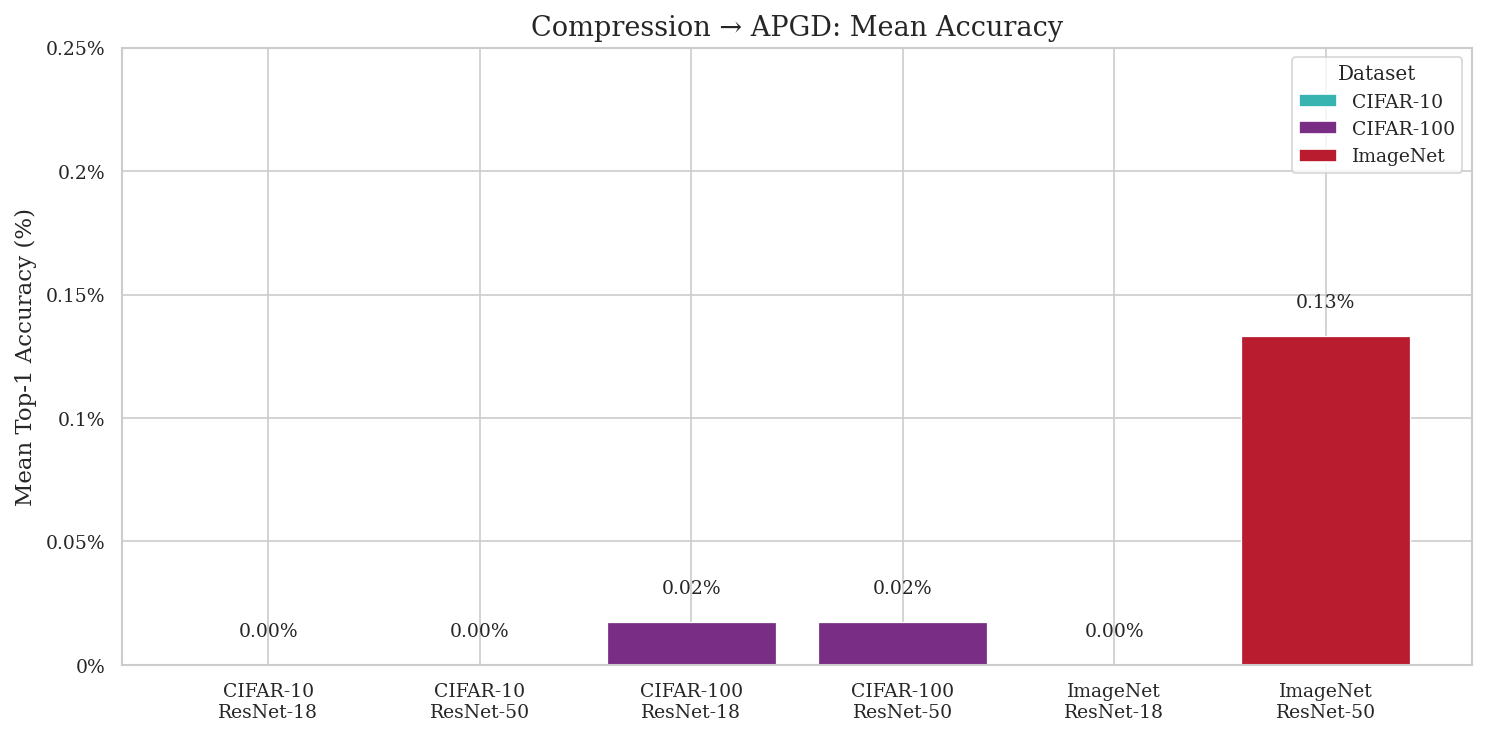

In [97]:
# Caption: Mean Top-1 accuracy of Compression→APGD pipelines across all compression
#          methods and quality levels, for each dataset–model pair. Averaged over all
#          15 (CIFAR) or 15 (ImageNet) Compression→Attack configurations per model,
#          every pair sits at or near 0% — confirming that iterative APGD attacks fully
#          saturate the classifier regardless of preprocessing method or quality level,
#          and that compression applied before the attack provides no protective benefit.
# Supports: 5.5 Compound pipeline floor-effect paragraph — APGD saturates across all
#           compression methods, quality levels, and datasets.

comp_apgd = df_all[
    (df_all['pipeline_type'] == 'Compound (Comp→Attack)') &
    (df_all['attack'] == 'apgd')
].copy()
comp_apgd['model_arch'] = comp_apgd['model_arch'].str.replace('resnet', 'ResNet-', regex=False)

dataset_order = ['CIFAR-10', 'CIFAR-100', 'ImageNet']
agg = (comp_apgd
       .groupby(['dataset', 'model_arch'], as_index=False)['accuracy']
       .mean())
agg['dataset'] = pd.Categorical(agg['dataset'], categories=dataset_order, ordered=True)
agg = agg.sort_values(['dataset', 'model_arch']).reset_index(drop=True)
agg['label'] = agg['dataset'].astype(str) + '\n' + agg['model_arch']

fig, ax = plt.subplots(figsize=(10, 5))
colours = [PALETTE_DATASETS[d] for d in agg['dataset']]
bars = ax.bar(range(len(agg)), agg['accuracy'] * 100,
              color=colours, edgecolor='white', linewidth=0.6)

for bar, (_, row) in zip(bars, agg.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{row['accuracy']*100:.2f}%",
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(range(len(agg)))
ax.set_xticklabels(agg['label'], fontsize=9)
ax.set_ylabel('Mean Top-1 Accuracy (%)')
ax.set_ylim(0, 0.25)
ax.set_title('Compression → APGD: Mean Accuracy')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=PALETTE_DATASETS[d], label=d) for d in dataset_order]
ax.legend(handles=legend_elements, title='Dataset', frameon=True)

plt.tight_layout()
save_fig('comp_attack_apgd_floor_effect')
plt.show()

Saved → Results/Figures/comp_fgsm_amplification_cifar.png


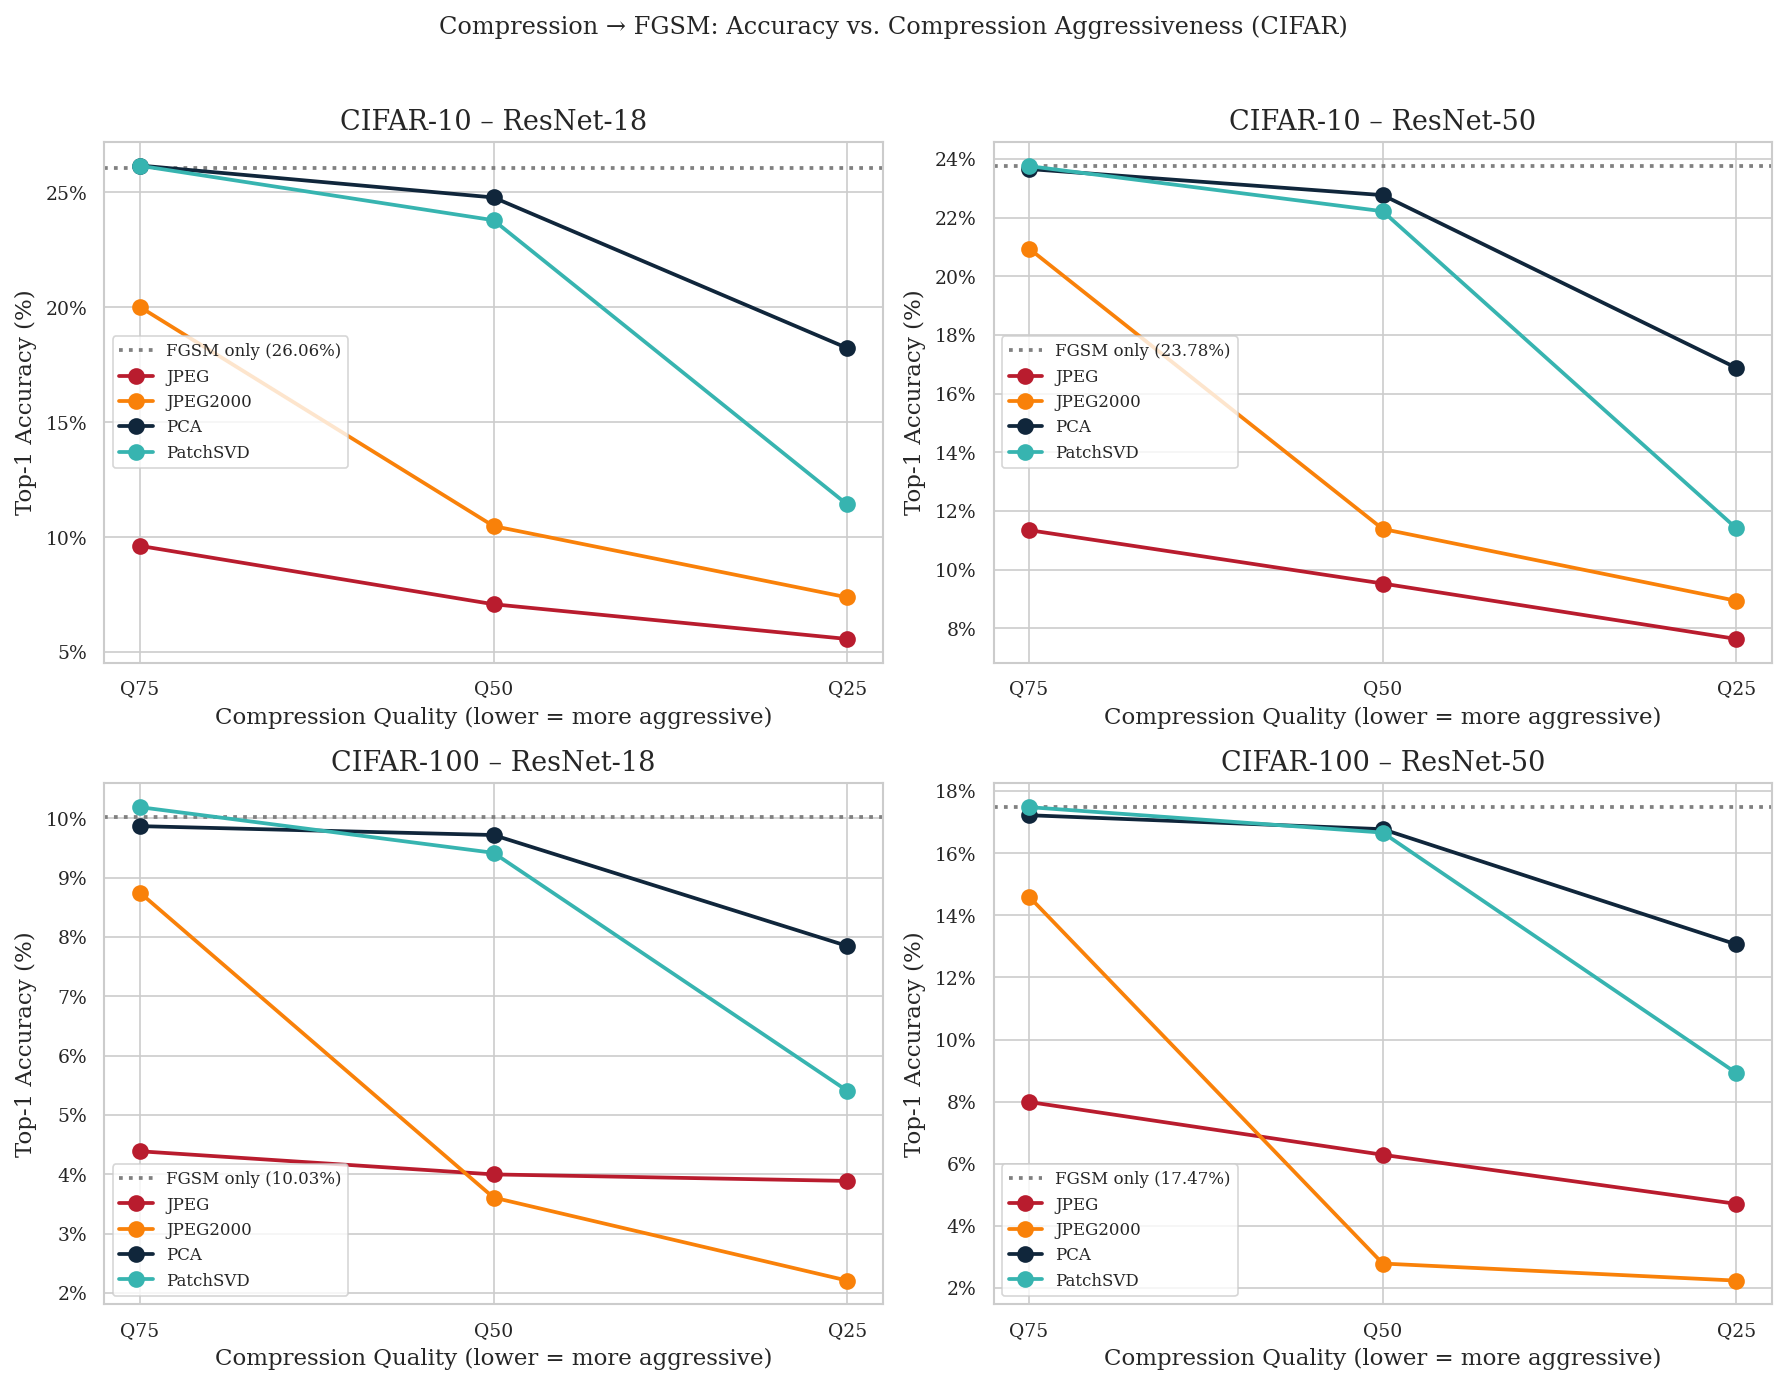

In [98]:
# Caption: Top-1 accuracy of Compression→FGSM pipelines across quality levels 25%, 50%,
#          and 75% for all compression methods, shown in a 2×2 grid by dataset and
#          architecture. Horizontal dotted lines mark the FGSM-only baseline for each
#          panel. Compression before FGSM almost universally reduces accuracy below the
#          uncompressed baseline, and the reduction scales monotonically with compression
#          aggressiveness — confirming that preprocessing amplifies rather than attenuates
#          the attack when the perturbation is crafted on the compressed image.
# Supports: 5.5 FGSM amplification paragraph — compression→FGSM monotonic degradation.

comp_fgsm = df_cifar[
    (df_cifar['pipeline_type'] == 'Compound (Comp→Attack)') &
    (df_cifar['attack'] == 'fgsm')
].copy()
comp_fgsm['model_arch'] = comp_fgsm['model_arch'].str.replace('resnet', 'ResNet-', regex=False)
comp_fgsm['comp_label'] = comp_fgsm['compression'].map(COMP_LABELS)

fgsm_only = df_cifar[
    (df_cifar['pipeline_type'] == 'Attack Only') &
    (df_cifar['attack'] == 'fgsm')
].copy()
fgsm_only['model_arch'] = fgsm_only['model_arch'].str.replace('resnet', 'ResNet-', regex=False)

COMP_PALETTE = {
    'JPEG':     UON_RED,
    'JPEG2000': UON_ORANGE,
    'PCA':      UON_BLUE,
    'PatchSVD': UON_TURQUOISE,
}

quality_order = [25, 50, 75]
panels = [
    ('CIFAR-10',  'ResNet-18'),
    ('CIFAR-10',  'ResNet-50'),
    ('CIFAR-100', 'ResNet-18'),
    ('CIFAR-100', 'ResNet-50'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=False)
axes_flat = axes.flatten()

for ax, (dataset, arch) in zip(axes_flat, panels):
    sub = comp_fgsm[
        (comp_fgsm['dataset'] == dataset) &
        (comp_fgsm['model_arch'] == arch)
    ]

    # FGSM-only baseline
    baseline = fgsm_only[
        (fgsm_only['dataset'] == dataset) &
        (fgsm_only['model_arch'] == arch)
    ]['accuracy'].values[0] * 100
    ax.axhline(baseline, color='grey', linestyle=':', linewidth=1.8,
               label=f'FGSM only ({baseline:.2f}%)')

    for comp, colour in COMP_PALETTE.items():
        row = sub[sub['comp_label'] == comp].sort_values('quality')
        if row.empty:
            continue
        accs = [row[row['quality'] == q]['accuracy'].values[0] * 100
                for q in quality_order]
        ax.plot(quality_order, accs,
                color=colour, marker='o', linewidth=1.8, markersize=7,
                label=comp)

    ax.set_title(f'{dataset} – {arch}')
    ax.set_xticks(quality_order)
    ax.set_xticklabels([f'Q{q}' for q in quality_order])
    ax.set_xlabel('Compression Quality (lower = more aggressive)')
    ax.set_ylabel('Top-1 Accuracy (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.invert_xaxis()
    ax.legend(frameon=True, fontsize=8)

fig.suptitle('Compression → FGSM: Accuracy vs. Compression Aggressiveness (CIFAR)', y=1.02)
plt.tight_layout()
save_fig('comp_fgsm_amplification_cifar')
plt.show()

Saved → Results/Figures/comp_fgsm_amplification_imagenet.png


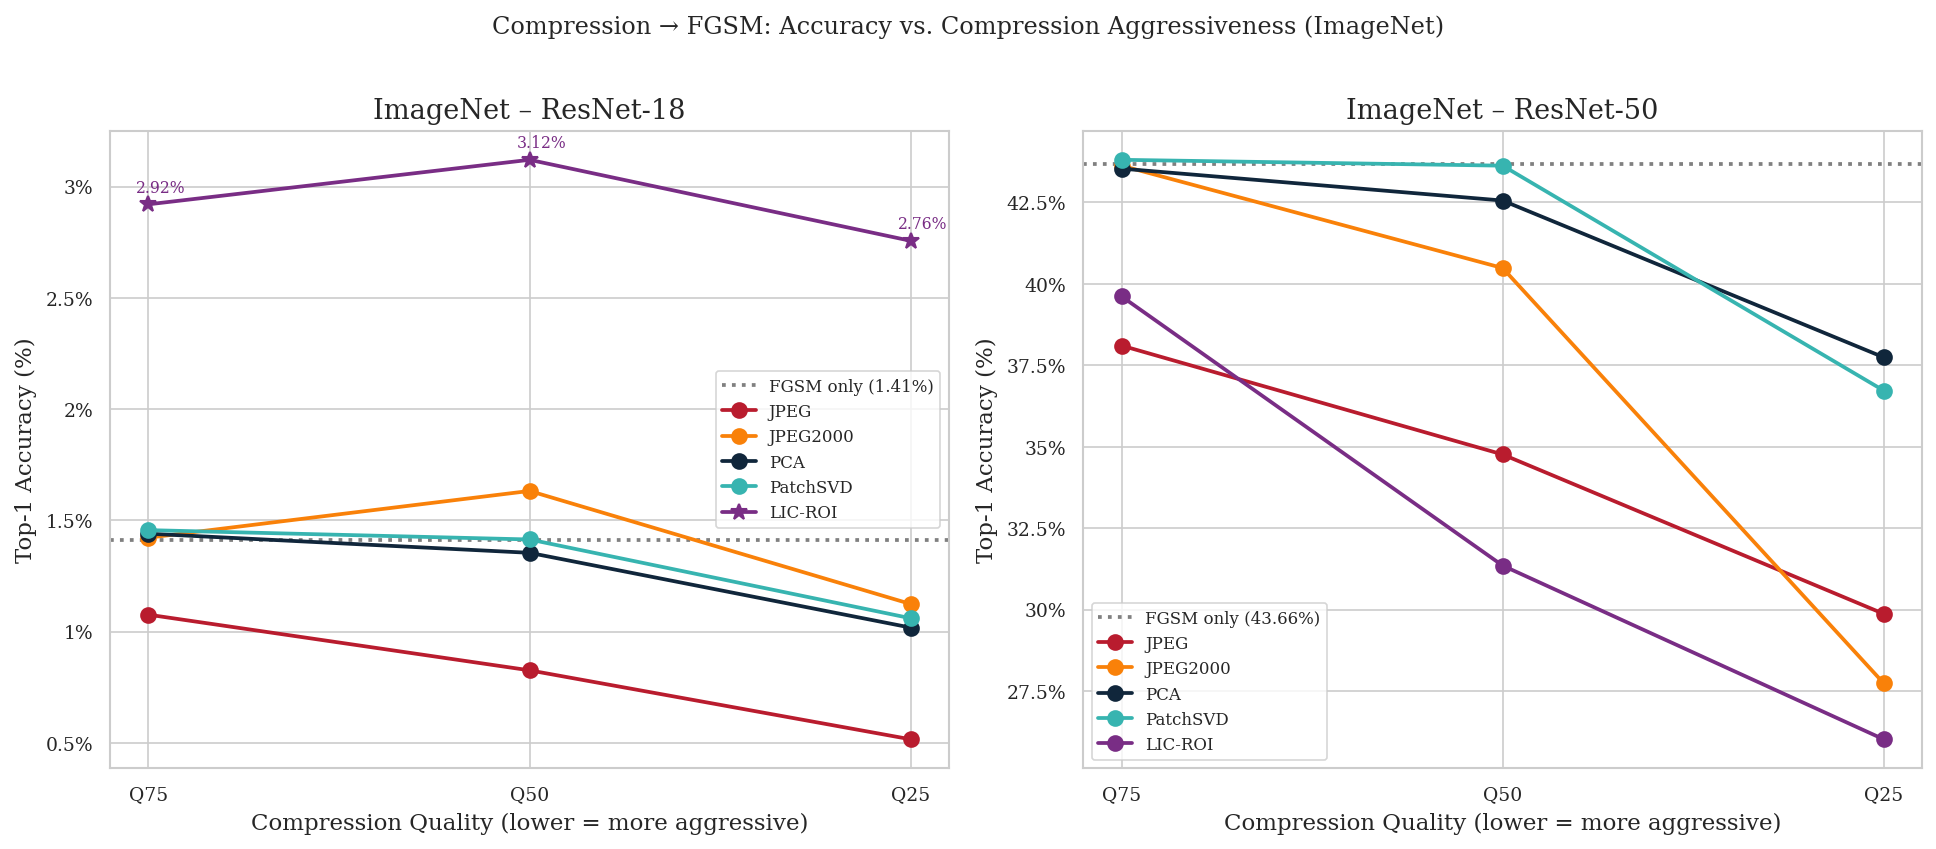

In [99]:
# Caption: Top-1 accuracy of Compression→FGSM pipelines on ImageNet across quality
#          levels 25%, 50%, and 75% for all five compression methods, shown separately
#          for ResNet-18 (left) and ResNet-50 (right). Horizontal dotted lines mark the
#          FGSM-only baseline for each model. For ResNet-50, every configuration falls
#          below the 43.66% baseline with amplification scaling monotonically with
#          compression aggressiveness. For ResNet-18, the near-zero FGSM baseline (1.41%)
#          masks amplification via a floor effect; LIC-ROI→FGSM paradoxically yields
#          slightly higher accuracy (2.76–3.12%) due to the learned codec's distribution
#          shift degrading FGSM's gradient quality on the compressed representation.
# Supports: 5.5 ImageNet FGSM amplification paragraph — monotonic amplification for
#           ResNet-50; floor effect and LIC-ROI anomaly for ResNet-18.

comp_fgsm_in = df_imagenet[
    (df_imagenet['pipeline_type'] == 'Compound (Comp→Attack)') &
    (df_imagenet['attack'] == 'fgsm')
].copy()
comp_fgsm_in['model_arch'] = comp_fgsm_in['model_arch'].str.replace('resnet', 'ResNet-', regex=False)
comp_fgsm_in['comp_label'] = comp_fgsm_in['compression'].map(COMP_LABELS)

fgsm_only_in = df_imagenet[
    (df_imagenet['pipeline_type'] == 'Attack Only') &
    (df_imagenet['attack'] == 'fgsm')
].copy()
fgsm_only_in['model_arch'] = fgsm_only_in['model_arch'].str.replace('resnet', 'ResNet-', regex=False)

COMP_PALETTE_IN = {
    'JPEG':     UON_RED,
    'JPEG2000': UON_ORANGE,
    'PCA':      UON_BLUE,
    'PatchSVD': UON_TURQUOISE,
    'LIC-ROI':  UON_PURPLE,
}

quality_order = [25, 50, 75]
panels = [('ResNet-18', 'left'), ('ResNet-50', 'right')]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=False)

for ax, (arch, _) in zip(axes, panels):
    sub = comp_fgsm_in[comp_fgsm_in['model_arch'] == arch]

    baseline = fgsm_only_in[
        fgsm_only_in['model_arch'] == arch
    ]['accuracy'].values[0] * 100
    ax.axhline(baseline, color='grey', linestyle=':', linewidth=1.8,
               label=f'FGSM only ({baseline:.2f}%)')

    for comp, colour in COMP_PALETTE_IN.items():
        row = sub[sub['comp_label'] == comp].sort_values('quality')
        if row.empty:
            continue
        accs = [row[row['quality'] == q]['accuracy'].values[0] * 100
                if len(row[row['quality'] == q]) else None
                for q in quality_order]
        # Annotate LIC-ROI on RN18 to highlight the anomaly
        ls = '-'
        marker = 'o'
        if comp == 'LIC-ROI' and arch == 'ResNet-18':
            ls = '-'
            marker = '*'
        ax.plot(quality_order, accs,
                color=colour, linestyle=ls, marker=marker,
                linewidth=1.8, markersize=8 if marker == '*' else 7,
                label=comp)

    # Annotate LIC-ROI anomaly on ResNet-18
    if arch == 'ResNet-18':
        lic_rows = sub[sub['comp_label'] == 'LIC-ROI'].sort_values('quality')
        for _, r in lic_rows.iterrows():
            ax.annotate(f"{r['accuracy']*100:.2f}%",
                        xy=(r['quality'], r['accuracy']*100),
                        xytext=(-6, 6), textcoords='offset points',
                        fontsize=7.5, color=UON_PURPLE)

    ax.set_title(f'ImageNet – {arch}')
    ax.set_xticks(quality_order)
    ax.set_xticklabels([f'Q{q}' for q in quality_order])
    ax.set_xlabel('Compression Quality (lower = more aggressive)')
    ax.set_ylabel('Top-1 Accuracy (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.invert_xaxis()
    ax.legend(frameon=True, fontsize=8)

fig.suptitle('Compression → FGSM: Accuracy vs. Compression Aggressiveness (ImageNet)', y=1.02)
plt.tight_layout()
save_fig('comp_fgsm_amplification_imagenet')
plt.show()

Saved → Results/Figures/jpeg_defence_quality_curves.png


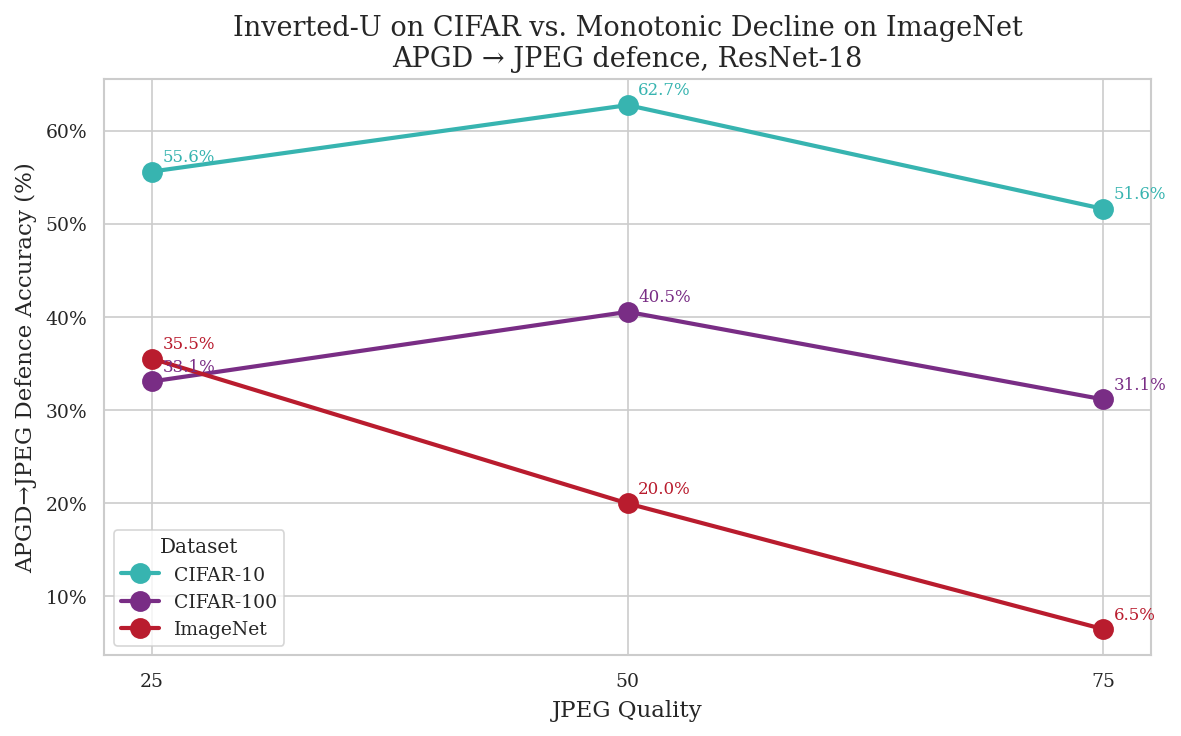

In [100]:
# Caption: APGD → JPEG defence Top-1 accuracy as a function of JPEG quality (25, 50, 75)
#          for CIFAR-10, CIFAR-100 and ImageNet (ResNet-18). CIFAR datasets show the
#          inverted-U shape that peaks at Q50, whereas ImageNet shows a monotonic decline
#          with increasing quality — the greater spatial redundancy of 224×224 imagery
#          means aggressive Q25 compression still preserves clean-image structure while
#          stripping more adversarial signal.
# Supports: 5.6 Perception–robustness trade-off paragraph — inverted-U on CIFAR versus
#           monotonic decline on ImageNet.

def_jpeg_all = df_all[
    (df_all['pipeline_type'] == 'Defend (Attack→Comp)') &
    (df_all['compression'] == 'jpeg') &
    (df_all['attack'] == 'apgd')
].copy()
def_jpeg_all['model_arch'] = def_jpeg_all['model_arch'].str.replace('resnet', 'ResNet-', regex=False)
# ResNet-18 only for a clean contrast
r18 = def_jpeg_all[def_jpeg_all['model_arch'] == 'ResNet-18']

fig, ax = plt.subplots(figsize=(8, 5))

for dataset in ['CIFAR-10', 'CIFAR-100', 'ImageNet']:
    sub = r18[r18['dataset'] == dataset].sort_values('quality')
    ax.plot(sub['quality'], sub['accuracy'] * 100,
            color=PALETTE_DATASETS[dataset], marker='o',
            linewidth=2, markersize=9, label=dataset)
    for _, row in sub.iterrows():
        ax.annotate(f"{row['accuracy']*100:.1f}%",
                    xy=(row['quality'], row['accuracy']*100),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, color=PALETTE_DATASETS[dataset])

ax.set_xlabel('JPEG Quality')
ax.set_ylabel('APGD→JPEG Defence Accuracy (%)')
ax.set_xticks([25, 50, 75])
ax.set_title('Inverted-U on CIFAR vs. Monotonic Decline on ImageNet\nAPGD → JPEG defence, ResNet-18')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax.legend(title='Dataset', frameon=True)

plt.tight_layout()
save_fig('jpeg_defence_quality_curves')
plt.show()

Saved → Results/Figures/relative_recovery_architecture_dataset.png


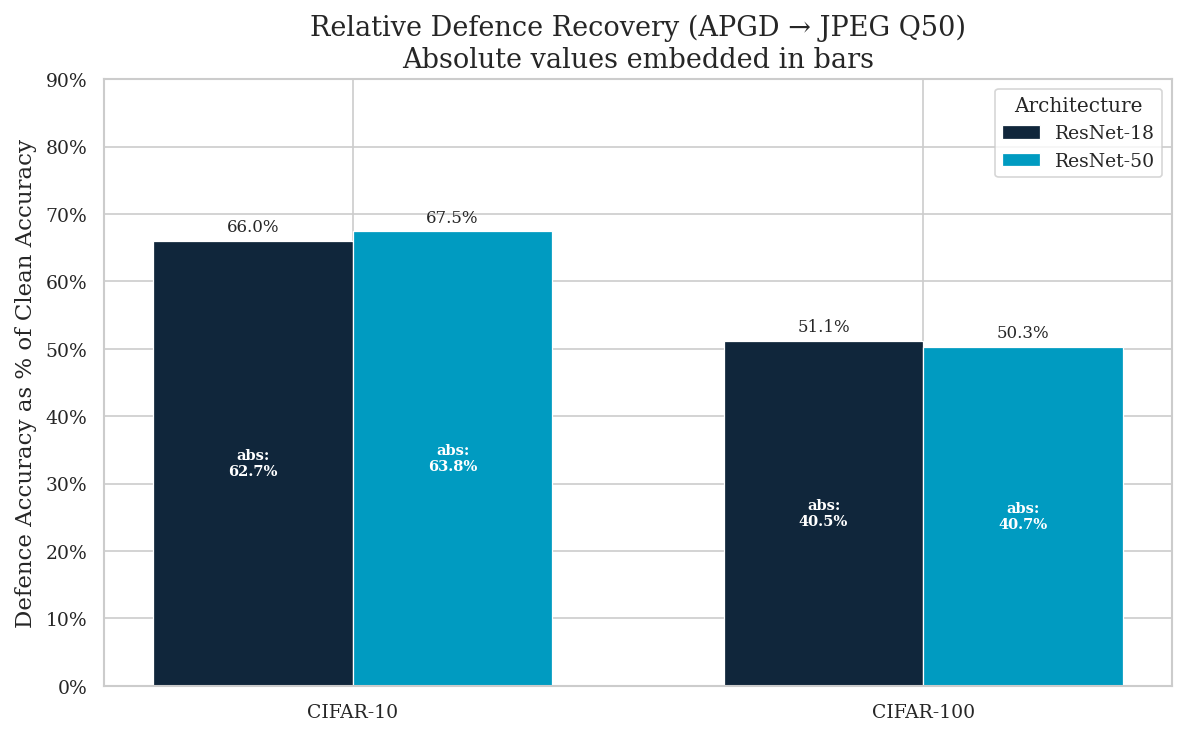

In [101]:
# Caption: Relative defence recovery (APGD → JPEG Q50 accuracy divided by clean accuracy)
#          for ResNet-18 and ResNet-50 across CIFAR-10 and CIFAR-100. Although absolute
#          recovered accuracy is lower on CIFAR-100 than CIFAR-10, the relative recovery —
#          i.e. the proportion of clean accuracy restored — is broadly similar across both
#          architectures and both datasets, indicating that JPEG-based purification is
#          approximately scale-invariant in classification complexity.
# Supports: 5.7 Dataset complexity paragraph — relative rather than absolute recovery is
#           what remains consistent across datasets.

def_q50 = df_cifar[
    (df_cifar['pipeline_type'] == 'Defend (Attack→Comp)') &
    (df_cifar['compression'] == 'jpeg') &
    (df_cifar['quality'] == 50) &
    (df_cifar['attack'] == 'apgd')
].copy()
clean_cifar = df_cifar[df_cifar['pipeline_type'] == 'Clean'][['dataset', 'model', 'accuracy']]
clean_cifar = clean_cifar.rename(columns={'accuracy': 'clean_acc'})

merged = def_q50.merge(clean_cifar, on=['dataset', 'model'])
merged['relative'] = merged['accuracy'] / merged['clean_acc'] * 100
merged['model_arch'] = merged['model_arch'].str.replace('resnet', 'ResNet-', regex=False)

fig, ax = plt.subplots(figsize=(8, 5))
datasets = ['CIFAR-10', 'CIFAR-100']
arch_order = ['ResNet-18', 'ResNet-50']
x = np.arange(len(datasets))
width = 0.35

for i, arch in enumerate(arch_order):
    vals = [merged[(merged['dataset'] == d) &
                   (merged['model_arch'] == arch)]['relative'].values[0]
            for d in datasets]
    bars = ax.bar(x + (i - 0.5) * width, vals, width,
                  label=arch, color=PALETTE_MODELS[arch],
                  edgecolor='white', linewidth=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.8,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

    # Also annotate absolute values subtly
    for bar, d in zip(bars, datasets):
        abs_val = merged[(merged['dataset'] == d) &
                         (merged['model_arch'] == arch)]['accuracy'].values[0] * 100
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() / 2,
                f'abs:\n{abs_val:.1f}%', ha='center', va='center',
                fontsize=7, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.set_ylabel('Defence Accuracy as % of Clean Accuracy')
ax.set_ylim(0, 90)
ax.set_title('Relative Defence Recovery (APGD → JPEG Q50)\nAbsolute values embedded in bars')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax.legend(title='Architecture', frameon=True)

plt.tight_layout()
save_fig('relative_recovery_architecture_dataset')
plt.show()

Saved → Results/Figures/rn18_vs_rn50_all_pipelines.png


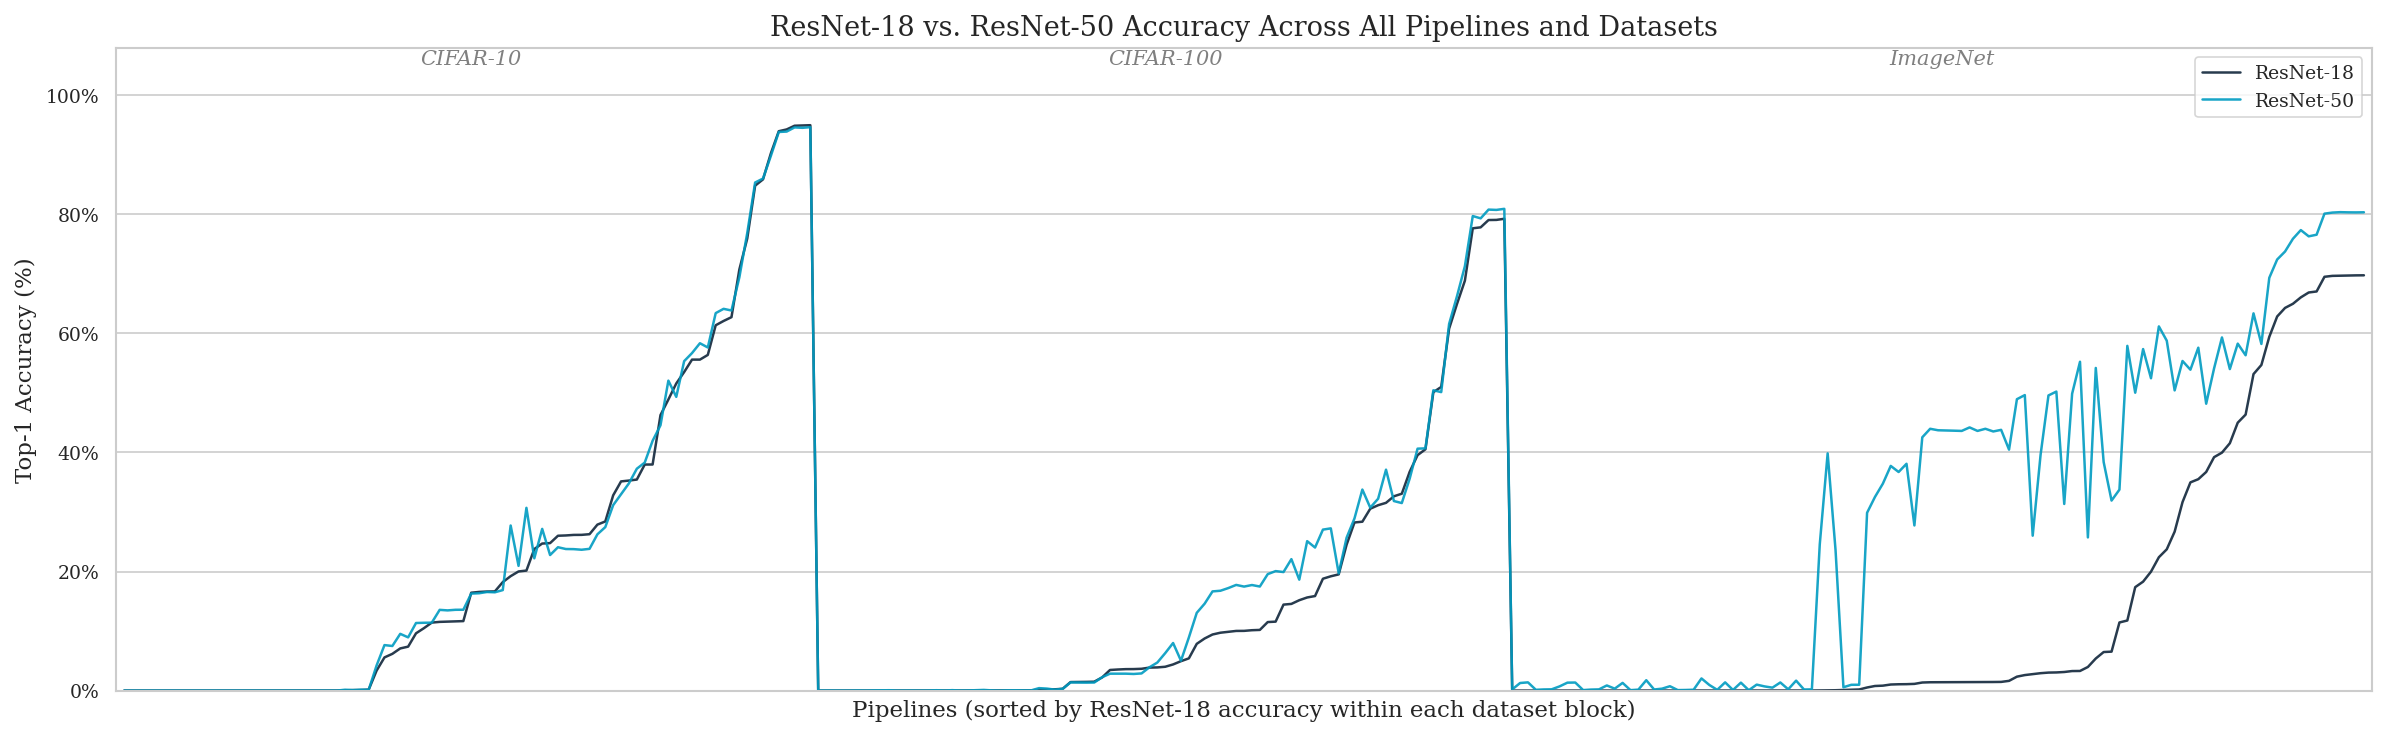

In [108]:
# Caption: Top-1 accuracy for every evaluated pipeline across CIFAR-10, CIFAR-100,
#          and ImageNet (left to right), with one line per architecture. Within each
#          dataset block, pipelines are sorted by ResNet-18 accuracy so the relative
#          positioning of the two lines is easily read. ResNet-50 (sky blue) sits
#          consistently at or marginally above ResNet-18 (dark blue) across CIFAR
#          pipelines; the most visible separation occurs on ImageNet under adversarial
#          pipelines, driven by ResNet-50's 43.66% vs ResNet-18's 1.41% FGSM resistance.
#          X-axis pipeline labels are omitted for legibility; vertical dashed lines
#          separate dataset blocks.
# Supports: 5.7 Architecture paragraph — ResNet-50 consistently matches or marginally
#           outperforms ResNet-18 across all conditions; ImageNet FGSM gap is the
#           most informative architectural contrast.

dataset_blocks = [
    ('CIFAR-10',  'resnet18_cifar10',   'resnet50_cifar10'),
    ('CIFAR-100', 'resnet18_cifar100',  'resnet50_cifar100'),
    ('ImageNet',  'resnet18_imagenet',  'resnet50_imagenet'),
]

rn18_accs, rn50_accs = [], []
block_boundaries = []  # x positions where each dataset block starts
block_midpoints   = []
x = 0

for dataset, m18, m50 in dataset_blocks:
    sub = df_all[df_all['dataset'] == dataset]
    s18 = sub[sub['model'] == m18][['pipeline', 'accuracy']].rename(columns={'accuracy': 'acc18'})
    s50 = sub[sub['model'] == m50][['pipeline', 'accuracy']].rename(columns={'accuracy': 'acc50'})
    merged = s18.merge(s50, on='pipeline').sort_values('acc18').reset_index(drop=True)

    block_boundaries.append(x)
    block_midpoints.append(x + len(merged) / 2)

    rn18_accs.extend(merged['acc18'].tolist())
    rn50_accs.extend(merged['acc50'].tolist())
    x += len(merged)

n = len(rn18_accs)
xs = list(range(n))

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(xs, [v * 100 for v in rn18_accs],
        color=UON_BLUE, linewidth=1.2, label='ResNet-18', alpha=0.9)
ax.plot(xs, [v * 100 for v in rn50_accs],
        color=UON_SKY,  linewidth=1.2, label='ResNet-50', alpha=0.9)

# Dataset block separators and labels
for i, (bx, label) in enumerate(zip(block_boundaries, [])):
    if i > 0:
        ax.axvline(bx - 0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.text(block_midpoints[i], ax.get_ylim()[1] if i == 0 else 103,
            label, ha='center', va='bottom', fontsize=10, color='grey')

ax.set_xlim(-1, n)
ax.set_ylim(0, 108)
ax.set_xticks([])
ax.set_xlabel('Pipelines (sorted by ResNet-18 accuracy within each dataset block)')
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_title('ResNet-18 vs. ResNet-50 Accuracy Across All Pipelines and Datasets')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax.legend(frameon=True)

# Re-draw dataset labels now that ylim is set
for bx, label in zip(block_midpoints, ['CIFAR-10', 'CIFAR-100', 'ImageNet']):
    ax.text(bx, 104.5, label, ha='center', va='bottom', fontsize=10,
            color='grey', fontstyle='italic')

plt.tight_layout()
save_fig('rn18_vs_rn50_all_pipelines')
plt.show()